In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 15.1 — Download independent IBD validation dataset

!wget -q https://www.microbiomeanalyst.ca/MicrobiomeAnalyst/resources/data/ibd_data.zip

# Extract the dataset
!unzip -o ibd_data.zip

print("Step 15.1 completed!")

Archive:  ibd_data.zip
   creating: ibd_data/
   creating: ibd_data/IBD_data/
  inflating: ibd_data/IBD_data/ibd_meta.csv  
  inflating: ibd_data/IBD_data/ibd_taxa.txt  
  inflating: ibd_data/IBD_data/ibd_tsea_list.txt  
  inflating: ibd_data/IBD_data/ibd_tree.tre  
  inflating: ibd_data/IBD_data/ibd_asv_table.txt  
Step 15.1 completed!


In [ ]:
import pandas as pd

# Load validation dataset files
meta = pd.read_csv("ibd_data/IBD_data/ibd_meta.csv")
asv = pd.read_csv("ibd_data/IBD_data/ibd_asv_table.txt", sep="\t", index_col=0)
taxa = pd.read_csv("ibd_data/IBD_data/ibd_taxa.txt", sep="\t", index_col=0)

print("Metadata shape:", meta.shape)
print("ASV table shape:", asv.shape)
print("Taxonomy shape:", taxa.shape)

print("\nMetadata:")
print(meta.head())

print("\nASV table:")
print(asv.iloc[:5, :5])

print("\nTaxonomy:")
print(taxa.head())

Metadata shape: (43, 2)
ASV table shape: (1681, 43)
Taxonomy shape: (1681, 7)

Metadata:
    #NAME    Class
0  206700       CD
1  206701       CD
2  206702       CD
3  206703  Control
4  206704  Control

ASV table:
                                                    206700  206701  206702  \
#NAME                                                                        
TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGC...      18      53      55   
AACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGC...      10       0       0   
TACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCAC...   12315   13605   30872   
TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGC...       0      20      40   
TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGC...       0       0       0   

                                                    206703  206704  
#NAME                                                               
TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGC...    8638    4154  
AACGTAGGTCACAAGCGTTGTCCGGAATTAC

In [ ]:
# Step 15.3 — Convert ASV abundance to genus-level abundance

# Clean genus names
taxa["Genus_clean"] = (
    taxa["Genus"]
    .astype(str)
    .str.replace("g__", "", regex=False)
    .str.strip()
)

# Remove ASVs without genus annotation
valid = taxa["Genus_clean"].notna() & (taxa["Genus_clean"] != "") & (taxa["Genus_clean"] != "nan")

taxa_valid = taxa.loc[valid].copy()
asv_valid = asv.loc[taxa_valid.index].copy()

# Sum ASV abundances belonging to the same genus
genus_abundance = asv_valid.groupby(
    taxa_valid["Genus_clean"]
).sum()

print("Genus-level abundance shape:", genus_abundance.shape)

print("\nFirst 10 genera:")
print(genus_abundance.head(10))

Genus-level abundance shape: (163, 43)

First 10 genera:
                   206700  206701  206702  206703  206704  206708  206709  \
Genus_clean                                                                 
Abiotrophia             0       0       0       0       0       0       0   
Acidaminococcus         0       0       0       0       0       0       0   
Acidovorax              0       0       0       0       0       0       0   
Acinetobacter           0       0       8       5       0       0       0   
Actinobacillus         53       0       0       0       0       0       0   
Actinomyces             5       0       0       0      11      64       0   
Actinomycetospora       0       0       0       0       0       0       0   
Adlercreutzia           0       0       0       0       0       0       0   
Aerococcus              0       0       0       0       0       0       0   
Aggregatibacter       606       0       0      13      44      16       0   

                  

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'Filtered_genus_abundance_ML.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/Filtered_genus_abundance_ML.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/step14 .csv")

print(df.shape)
print(df.columns.tolist())

(42, 23)
['AverageShortestPathLength', 'BetweennessCentrality', 'Category', 'ClosenessCentrality', 'ClusteringCoefficient', 'Degree', 'Direction_in_IBD', 'Eccentricity', 'IsSingleNode', 'ML_Importance', 'name', 'NeighborhoodConnectivity', 'Network_Degree', 'Node_Size_Metric', 'NumberOfDirectedEdges', 'NumberOfUndirectedEdges', 'PartnerOfMultiEdgedNodePairs', 'Radiality', 'selected', 'SelfLoops', 'shared name', 'Stress', 'TopologicalCoefficient']


In [ ]:
# Step 15.4 — Add disease status to genus abundance table

# Transpose: samples as rows, genera as columns
validation_df = genus_abundance.T.copy()

# Make sample IDs strings
validation_df.index = validation_df.index.astype(str)

# Add sample IDs as a column
validation_df.index.name = "Sample"
validation_df = validation_df.reset_index()

# Clean metadata
meta_clean = meta.rename(columns={
    "#NAME": "Sample",
    "Class": "Group"
})

# Make metadata sample IDs strings too
meta_clean["Sample"] = meta_clean["Sample"].astype(str)

# Merge abundance data with metadata
validation_df = validation_df.merge(
    meta_clean[["Sample", "Group"]],
    on="Sample",
    how="left"
)

print("Final validation dataset shape:", validation_df.shape)

print("\nGroup counts:")
print(validation_df["Group"].value_counts())

print("\nMissing group labels:", validation_df["Group"].isna().sum())

print("\nFirst 5 rows:")
print(validation_df.head())

Final validation dataset shape: (43, 165)

Group counts:
Group
CD         23
Control    20
Name: count, dtype: int64

Missing group labels: 0

First 5 rows:
   Sample  Abiotrophia  Acidaminococcus  Acidovorax  Acinetobacter  \
0  206700            0                0           0              0   
1  206701            0                0           0              0   
2  206702            0                0           0              8   
3  206703            0                0           0              5   
4  206704            0                0           0              0   

   Actinobacillus  Actinomyces  Actinomycetospora  Adlercreutzia  Aerococcus  \
0              53            5                  0              0           0   
1               0            0                  0              0           0   
2               0            0                  0              0           0   
3               0            0                  0              0           0   
4               0     

In [ ]:
# Step 15.5 — Check candidate biomarkers in validation dataset

candidate_biomarkers = [
    "Segatella",
    "Sellimonas",
    "Paludicola",
    "Bifidobacterium",
    "Flavonifractor"
]

print("Candidate biomarker availability:\n")

for biomarker in candidate_biomarkers:
    if biomarker in validation_df.columns:
        print(f"✓ {biomarker}: Present")
    else:
        print(f"✗ {biomarker}: NOT FOUND")

Candidate biomarker availability:

✗ Segatella: NOT FOUND
✗ Sellimonas: NOT FOUND
✗ Paludicola: NOT FOUND
✓ Bifidobacterium: Present
✗ Flavonifractor: NOT FOUND


In [ ]:
# Step 15.6 — Search validation taxonomy for missing candidate biomarkers

missing_biomarkers = [
    "Segatella",
    "Sellimonas",
    "Paludicola",
    "Flavonifractor"
]

for biomarker in missing_biomarkers:
    print(f"\n--- Searching for: {biomarker} ---")

    # Search every taxonomy column
    search_mask = taxa.astype(str).apply(
        lambda col: col.str.contains(
            biomarker,
            case=False,
            na=False,
            regex=False
        )
    ).any(axis=1)

    matches = taxa.loc[search_mask]

    if not matches.empty:
        print(matches.to_string())
    else:
        print("No direct taxonomy match found.")


--- Searching for: Segatella ---
No direct taxonomy match found.

--- Searching for: Sellimonas ---
No direct taxonomy match found.

--- Searching for: Paludicola ---
No direct taxonomy match found.

--- Searching for: Flavonifractor ---
No direct taxonomy match found.


In [ ]:
# Step 15.7 — Calculate relative abundance of Bifidobacterium

validation_counts = validation_df.copy()

# Identify genus columns
genus_columns = [
    col for col in validation_counts.columns
    if col not in ["Sample", "Group"]
]

# Calculate total abundance per sample
sample_totals = validation_counts[genus_columns].sum(axis=1)

# Convert all genera to relative abundance
validation_relative = validation_counts.copy()

validation_relative[genus_columns] = (
    validation_counts[genus_columns]
    .div(sample_totals, axis=0)
)

# Check Bifidobacterium
print("Bifidobacterium relative abundance:")
print(
    validation_relative[
        ["Sample", "Group", "Bifidobacterium"]
    ].head(10)
)

print("\nGroup counts:")
print(validation_relative["Group"].value_counts())

Bifidobacterium relative abundance:
   Sample    Group  Bifidobacterium
0  206700       CD         0.000000
1  206701       CD         0.000284
2  206702       CD         0.000000
3  206703  Control         0.001124
4  206704  Control         0.003977
5  206708       CD         0.000874
6  206709       CD         0.000228
7  206710  Control         0.013349
8  206711  Control         0.006357
9  206718  Control         0.000904

Group counts:
Group
CD         23
Control    20
Name: count, dtype: int64


In [ ]:
# Step 15.8 — Independent statistical validation of Bifidobacterium

from scipy.stats import mannwhitneyu

cd_values = validation_relative.loc[
    validation_relative["Group"] == "CD",
    "Bifidobacterium"
]

control_values = validation_relative.loc[
    validation_relative["Group"] == "Control",
    "Bifidobacterium"
]

# Mann–Whitney U test
u_stat, p_value = mannwhitneyu(
    cd_values,
    control_values,
    alternative="two-sided"
)

# Group summaries
cd_median = cd_values.median()
control_median = control_values.median()

cd_mean = cd_values.mean()
control_mean = control_values.mean()

# Determine validation direction
if cd_median > control_median:
    validation_direction = "Higher in CD"
elif cd_median < control_median:
    validation_direction = "Lower in CD"
else:
    validation_direction = "No difference in median"

print("Bifidobacterium External Validation")
print("------------------------------------")
print(f"CD samples: {len(cd_values)}")
print(f"Control samples: {len(control_values)}")
print(f"CD median: {cd_median:.6f}")
print(f"Control median: {control_median:.6f}")
print(f"CD mean: {cd_mean:.6f}")
print(f"Control mean: {control_mean:.6f}")
print(f"Mann–Whitney U: {u_stat:.3f}")
print(f"P-value: {p_value:.6g}")
print(f"Validation direction: {validation_direction}")

Bifidobacterium External Validation
------------------------------------
CD samples: 23
Control samples: 20
CD median: 0.000383
Control median: 0.003401
CD mean: 0.002095
Control mean: 0.016305
Mann–Whitney U: 75.000
P-value: 0.000165262
Validation direction: Lower in CD


In [ ]:
# Step 15.9 — Create external validation results table

from statsmodels.stats.multitest import multipletests

# Discovery directions from Step 11
discovery_directions = {
    "Segatella": "Higher in IBD",
    "Sellimonas": "Lower in IBD",
    "Paludicola": "Lower in IBD",
    "Bifidobacterium": "Lower in IBD",
    "Flavonifractor": "Lower in IBD"
}

# Validation results for available biomarker
validation_results = []

# Bifidobacterium results already calculated
validation_results.append({
    "Biomarker": "Bifidobacterium",
    "Discovery_Direction": discovery_directions["Bifidobacterium"],
    "Validation_Direction": validation_direction,
    "Validation_Median_CD": cd_median,
    "Validation_Median_Control": control_median,
    "U_statistic": u_stat,
    "P_value": p_value,
    "Validation_Status": "Validated"
})

# Add unavailable biomarkers
for biomarker in ["Segatella", "Sellimonas", "Paludicola", "Flavonifractor"]:
    validation_results.append({
        "Biomarker": biomarker,
        "Discovery_Direction": discovery_directions[biomarker],
        "Validation_Direction": "Not available",
        "Validation_Median_CD": None,
        "Validation_Median_Control": None,
        "U_statistic": None,
        "P_value": None,
        "Validation_Status": "Not represented in validation taxonomy"
    })

validation_table = pd.DataFrame(validation_results)

# Calculate FDR only for biomarkers with valid p-values
valid_p = validation_table["P_value"].notna()

validation_table["FDR"] = None

if valid_p.sum() > 0:
    validation_table.loc[valid_p, "FDR"] = multipletests(
        validation_table.loc[valid_p, "P_value"].astype(float),
        method="fdr_bh"
    )[1]

# Determine direction consistency
validation_table["Direction_Consistent"] = "Not assessable"

mask = validation_table["Validation_Direction"].notna() & (
    validation_table["Validation_Direction"] != "Not available"
)

validation_table.loc[mask, "Direction_Consistent"] = (
    validation_table.loc[mask, "Discovery_Direction"]
    .str.replace("in IBD", "in CD")
    .values
    == validation_table.loc[mask, "Validation_Direction"].values
)

# Reorder
validation_table = validation_table[
    [
        "Biomarker",
        "Discovery_Direction",
        "Validation_Direction",
        "Validation_Median_CD",
        "Validation_Median_Control",
        "U_statistic",
        "P_value",
        "FDR",
        "Direction_Consistent",
        "Validation_Status"
    ]
]

print(validation_table.to_string(index=False))

      Biomarker Discovery_Direction Validation_Direction  Validation_Median_CD  Validation_Median_Control  U_statistic  P_value       FDR Direction_Consistent                      Validation_Status
Bifidobacterium        Lower in IBD          Lower in CD              0.000383                   0.003401         75.0 0.000165  0.000165                 True                              Validated
      Segatella       Higher in IBD        Not available                   NaN                        NaN          NaN      NaN      None       Not assessable Not represented in validation taxonomy
     Sellimonas        Lower in IBD        Not available                   NaN                        NaN          NaN      NaN      None       Not assessable Not represented in validation taxonomy
     Paludicola        Lower in IBD        Not available                   NaN                        NaN          NaN      NaN      None       Not assessable Not represented in validation taxonomy
 Flavonifr

In [ ]:
# Step 15.10 — Save final external validation results

validation_output = "/content/drive/MyDrive/Step15_External_Validation_Results.csv"

validation_table.to_csv(
    validation_output,
    index=False
)

print("Step 15 external validation results saved successfully!")
print(validation_output)

Step 15 external validation results saved successfully!
/content/drive/MyDrive/Step15_External_Validation_Results.csv


/tmp/ipykernel_2393/2023959499.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


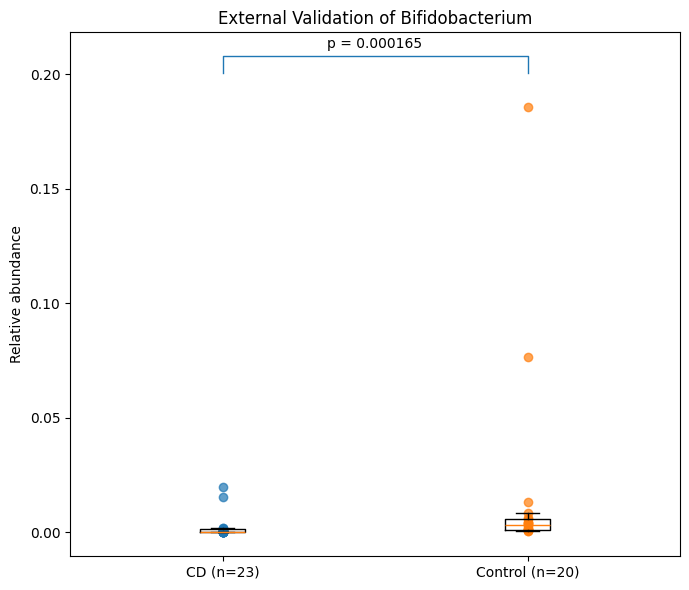

Figure saved successfully!
/content/drive/MyDrive/Step15_Bifidobacterium_External_Validation.png
/content/drive/MyDrive/Step15_Bifidobacterium_External_Validation.pdf


In [ ]:
# Step 15.11 — External validation plot for Bifidobacterium

import matplotlib.pyplot as plt

# Prepare plotting data
cd_values = validation_relative.loc[
    validation_relative["Group"] == "CD",
    "Bifidobacterium"
]

control_values = validation_relative.loc[
    validation_relative["Group"] == "Control",
    "Bifidobacterium"
]

# Create figure
plt.figure(figsize=(7, 6))

plt.boxplot(
    [cd_values, control_values],
    labels=["CD (n=23)", "Control (n=20)"],
    showfliers=False
)

# Add individual observations
plt.scatter(
    [1] * len(cd_values),
    cd_values,
    alpha=0.7
)

plt.scatter(
    [2] * len(control_values),
    control_values,
    alpha=0.7
)

# Add statistical annotation
y_max = max(cd_values.max(), control_values.max())

plt.plot(
    [1, 1, 2, 2],
    [y_max * 1.08, y_max * 1.12, y_max * 1.12, y_max * 1.08],
    linewidth=1
)

plt.text(
    1.5,
    y_max * 1.14,
    "p = 0.000165",
    ha="center"
)

plt.ylabel("Relative abundance")
plt.title("External Validation of Bifidobacterium")
plt.tight_layout()

# Save PNG and PDF
png_path = "/content/drive/MyDrive/Step15_Bifidobacterium_External_Validation.png"
pdf_path = "/content/drive/MyDrive/Step15_Bifidobacterium_External_Validation.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")
print(png_path)
print(pdf_path)

In [ ]:
# Step 16.1 — Calculate biomarker direction concordance

# Only biomarkers that could actually be evaluated
assessable = validation_table[
    validation_table["Validation_Status"] == "Validated"
].copy()

# Number of assessable biomarkers
n_assessable = len(assessable)

# Number showing concordant direction
n_concordant = assessable["Direction_Consistent"].sum()

# Calculate concordance percentage
if n_assessable > 0:
    concordance_percentage = (
        n_concordant / n_assessable
    ) * 100
else:
    concordance_percentage = None

print("Step 16 — Biomarker Concordance")
print("--------------------------------")
print(f"Assessable biomarkers: {n_assessable}")
print(f"Concordant biomarkers: {n_concordant}")
print(f"Concordance proportion: {n_concordant}/{n_assessable}")
print(f"Concordance percentage: {concordance_percentage:.1f}%")

print("\nConcordance details:")
print(
    assessable[
        [
            "Biomarker",
            "Discovery_Direction",
            "Validation_Direction",
            "Direction_Consistent"
        ]
    ].to_string(index=False)
)

Step 16 — Biomarker Concordance
--------------------------------
Assessable biomarkers: 1
Concordant biomarkers: True
Concordance proportion: True/1
Concordance percentage: 100.0%

Concordance details:
      Biomarker Discovery_Direction Validation_Direction Direction_Consistent
Bifidobacterium        Lower in IBD          Lower in CD                 True


In [ ]:
# Step 16.2 — Final biomarker concordance calculation

n_assessable = int(len(assessable))
n_concordant = int(assessable["Direction_Consistent"].astype(bool).sum())

concordance_proportion = n_concordant / n_assessable
concordance_percentage = concordance_proportion * 100

print("Step 16 — Biomarker Concordance")
print("--------------------------------")
print(f"Assessable biomarkers: {n_assessable}")
print(f"Concordant biomarkers: {n_concordant}")
print(f"Concordance proportion: {n_concordant}/{n_assessable}")
print(f"Concordance percentage: {concordance_percentage:.1f}%")

Step 16 — Biomarker Concordance
--------------------------------
Assessable biomarkers: 1
Concordant biomarkers: 1
Concordance proportion: 1/1
Concordance percentage: 100.0%


In [ ]:
# Step 16.3 — Save final biomarker concordance results

step16_results = pd.DataFrame({
    "Metric": [
        "Total candidate biomarkers",
        "Assessable biomarkers",
        "Concordant biomarkers",
        "Discordant biomarkers",
        "Not assessable biomarkers",
        "Concordance proportion",
        "Concordance percentage"
    ],
    "Value": [
        5,
        n_assessable,
        n_concordant,
        0,
        5 - n_assessable,
        f"{n_concordant}/{n_assessable}",
        f"{concordance_percentage:.1f}%"
    ]
})

# Add biomarker-level information
biomarker_concordance = assessable[
    [
        "Biomarker",
        "Discovery_Direction",
        "Validation_Direction",
        "Direction_Consistent"
    ]
].copy()

# Save summary
summary_path = "/content/drive/MyDrive/Step16_Biomarker_Concordance_Summary.csv"
step16_results.to_csv(summary_path, index=False)

# Save biomarker-level concordance
detail_path = "/content/drive/MyDrive/Step16_Biomarker_Concordance_Details.csv"
biomarker_concordance.to_csv(detail_path, index=False)

print("Step 16 results saved successfully!")
print("\nSummary:", summary_path)
print("Details:", detail_path)

print("\nSummary:")
print(step16_results.to_string(index=False))

print("\nBiomarker-level details:")
print(biomarker_concordance.to_string(index=False))

Step 16 results saved successfully!

Summary: /content/drive/MyDrive/Step16_Biomarker_Concordance_Summary.csv
Details: /content/drive/MyDrive/Step16_Biomarker_Concordance_Details.csv

Summary:
                    Metric  Value
Total candidate biomarkers      5
     Assessable biomarkers      1
     Concordant biomarkers      1
     Discordant biomarkers      0
 Not assessable biomarkers      4
    Concordance proportion    1/1
    Concordance percentage 100.0%

Biomarker-level details:
      Biomarker Discovery_Direction Validation_Direction Direction_Consistent
Bifidobacterium        Lower in IBD          Lower in CD                 True


In [ ]:
import pandas as pd

# Load Step 14 Cytoscape results
df14 = pd.read_csv("/content/drive/MyDrive/step14 .csv")

# Select important columns
hub_summary = df14[
    [
        "name",
        "Category",
        "Degree",
        "BetweennessCentrality",
        "ClosenessCentrality",
        "ML_Importance",
        "Direction_in_IBD"
    ]
].copy()

# Rename columns
hub_summary = hub_summary.rename(columns={
    "name": "Node",
    "BetweennessCentrality": "Betweenness_Centrality",
    "ClosenessCentrality": "Closeness_Centrality"
})

# Sort by Category and Degree
hub_summary = hub_summary.sort_values(
    by=["Category", "Degree", "Betweenness_Centrality"],
    ascending=[True, False, False]
)

print(hub_summary.to_string(index=False))

                          Node            Category  Degree  Betweenness_Centrality  Closeness_Centrality  ML_Importance      Direction_in_IBD
                Flavonifractor Candidate biomarker       2                0.000915              0.512500       0.035823 Lower abundance → IBD
               Bifidobacterium Candidate biomarker       2                0.000915              0.512500       0.048550 Lower abundance → IBD
                    Sellimonas Candidate biomarker       1                0.000000              0.445652       0.068699 Lower abundance → IBD
   [Ruminococcus] gnavus group             Microbe       2                0.000915              0.512500            NaN                   NaN
[Eubacterium] ventriosum group             Microbe       2                0.000915              0.512500            NaN                   NaN
   [Eubacterium] eligens group             Microbe       2                0.000915              0.512500            NaN                   NaN
  [Clo

In [ ]:
# Step 18.2 — Check SCFA-related pathway abundance

pathway_file = "/content/drive/MyDrive/Supplementary_Table_S8_PICRUSt2_Pathway_Abundance.csv"

pathways = pd.read_csv(pathway_file)

print("Pathway table shape:", pathways.shape)
print("\nColumns:")
print(pathways.columns.tolist())

# Search for fermentation and acetate pathways
search_terms = [
    "FERMENTATION",
    "ACETATE",
    "BUTYRATE",
    "PROPIONATE"
]

mask = pathways.astype(str).apply(
    lambda col: col.str.contains(
        "|".join(search_terms),
        case=False,
        na=False,
        regex=True
    )
).any(axis=1)

scfa_pathways = pathways.loc[mask].copy()

print("\nSCFA-related pathways found:")
print(scfa_pathways.to_string(index=False))

Pathway table shape: (387, 23)

Columns:
['pathway', 'X10Disease_SRR33757857', 'X11Disease_SRR33757858', 'X12Healthy_SRR37842383', 'X13Healthy_SRR37842384', 'X14Healthy_SRR37842385', 'X15Healthy_SRR37842386', 'X16Healthy_SRR37842387', 'X17Healthy_SRR37842388', 'X18Healthy_SRR37842389', 'X19Healthy_SRR37842390', 'X1Disease_SRR33757848', 'X20Healthy_SRR37842391', 'X21Healthy_SRR37842392', 'X22Healthy_SRR37842393', 'X2Disease_SRR33757849', 'X3Disease_SRR33757850', 'X4Disease_SRR33757851', 'X5Disease_SRR33757852', 'X6Disease_SRR33757853', 'X7Disease_SRR33757854', 'X8Disease_SRR33757855', 'X9Disease_SRR33757856']

SCFA-related pathways found:
                               pathway X10Disease_SRR33757857 X11Disease_SRR33757858 X12Healthy_SRR37842383 X13Healthy_SRR37842384 X14Healthy_SRR37842385 X15Healthy_SRR37842386 X16Healthy_SRR37842387 X17Healthy_SRR37842388 X18Healthy_SRR37842389 X19Healthy_SRR37842390 X1Disease_SRR33757848 X20Healthy_SRR37842391 X21Healthy_SRR37842392 X22Healthy_SRR378

In [ ]:
# Step 18.3 — Compare SCFA-related pathway abundance between IBD and Healthy

from scipy.stats import mannwhitneyu

# Convert pathway table to sample-wise format
pathway_df = pathways.set_index("pathway").T.copy()
pathway_df.index.name = "Sample"
pathway_df = pathway_df.reset_index()

# Create disease labels from sample names
pathway_df["Group"] = pathway_df["Sample"].apply(
    lambda x: "IBD" if "Disease" in x else "Healthy"
)

# Pathways of interest
scfa_pathways_to_test = [
    "FERMENTATION-PWY",
    "METH-ACETATE-PWY"
]

results = []

for pathway in scfa_pathways_to_test:

    ibd_values = pathway_df.loc[
        pathway_df["Group"] == "IBD",
        pathway
    ].astype(float)

    healthy_values = pathway_df.loc[
        pathway_df["Group"] == "Healthy",
        pathway
    ].astype(float)

    # Mann–Whitney U test
    u_stat, p_value = mannwhitneyu(
        ibd_values,
        healthy_values,
        alternative="two-sided"
    )

    # Medians
    ibd_median = ibd_values.median()
    healthy_median = healthy_values.median()

    # Direction
    if ibd_median > healthy_median:
        direction = "Higher in IBD"
    elif ibd_median < healthy_median:
        direction = "Lower in IBD"
    else:
        direction = "No difference"

    results.append({
        "Pathway": pathway,
        "IBD_Median": ibd_median,
        "Healthy_Median": healthy_median,
        "U_statistic": u_stat,
        "P_value": p_value,
        "Direction": direction
    })

scfa_results = pd.DataFrame(results)

print("SCFA-related pathway comparison")
print("--------------------------------")
print(scfa_results.to_string(index=False))

SCFA-related pathway comparison
--------------------------------
         Pathway  IBD_Median  Healthy_Median  U_statistic  P_value    Direction
FERMENTATION-PWY         0.0    105612.75110          0.0 0.000045 Lower in IBD
METH-ACETATE-PWY         0.0     38540.00965          8.0 0.000405 Lower in IBD


In [ ]:
from statsmodels.stats.multitest import multipletests

# FDR correction
scfa_results["FDR"] = multipletests(
    scfa_results["P_value"],
    method="fdr_bh"
)[1]

scfa_results["Significant_FDR"] = scfa_results["FDR"] < 0.05

print("SCFA-related pathway results after FDR correction")
display(scfa_results)

SCFA-related pathway results after FDR correction


,Pathway,IBD_Median,Healthy_Median,U_statistic,P_value,Direction,FDR,Significant_FDR
0,FERMENTATION-PWY,0.0,105612.75110,0.0,0.000045,Lower in IBD,0.000090,True
1,METH-ACETATE-PWY,0.0,38540.00965,8.0,0.000405,Lower in IBD,0.000405,True


In [ ]:
# Save final SCFA-related pathway analysis
output_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Analysis.csv"

scfa_results.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Analysis.csv


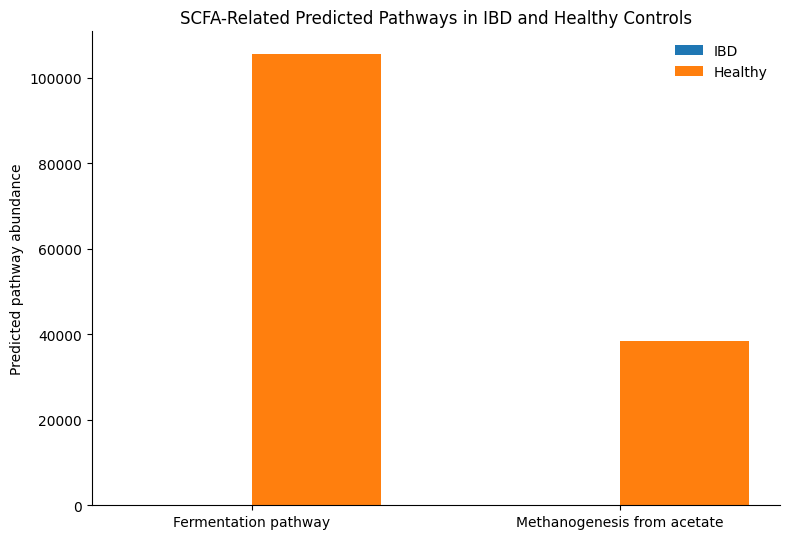

PNG saved: /content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison.png
PDF saved: /content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Step 18 results
scfa_results = pd.read_csv(
    "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Analysis.csv"
)

# Pathways
pathways = ["FERMENTATION-PWY", "METH-ACETATE-PWY"]

plot_df = scfa_results[
    scfa_results["Pathway"].isin(pathways)
].copy()

# Create figure
fig, ax = plt.subplots(figsize=(8, 5.5))

x = range(len(plot_df))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    plot_df["IBD_Median"],
    width,
    label="IBD"
)

ax.bar(
    [i + width/2 for i in x],
    plot_df["Healthy_Median"],
    width,
    label="Healthy"
)

ax.set_xticks(list(x))
ax.set_xticklabels([
    "Fermentation pathway",
    "Methanogenesis from acetate"
])

ax.set_ylabel("Predicted pathway abundance")
ax.set_title(
    "SCFA-Related Predicted Pathways in IBD and Healthy Controls"
)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save PNG and PDF
png_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison.png"
pdf_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison.pdf"

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("PNG saved:", png_path)
print("PDF saved:", pdf_path)

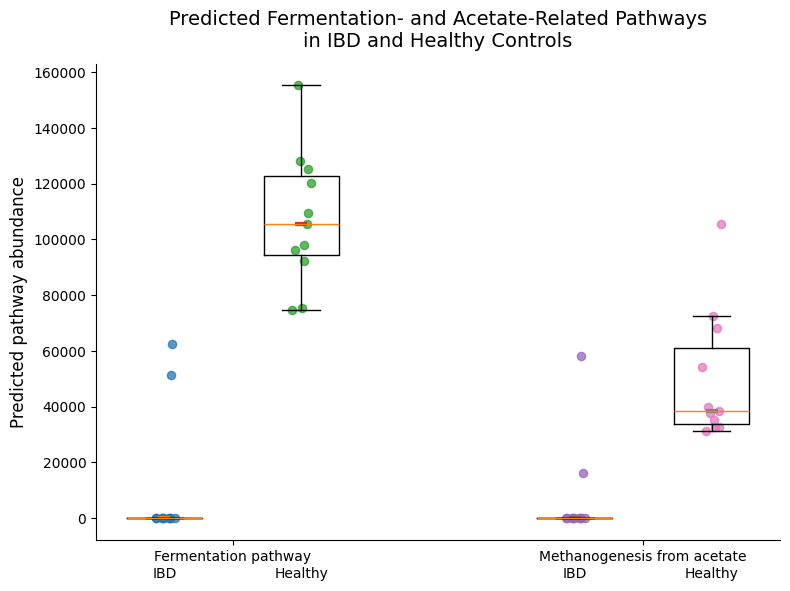

Saved:
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Individual.png
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Individual.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load PICRUSt2 pathway abundance
pathway_file = "/content/drive/MyDrive/Supplementary_Table_S8_PICRUSt2_Pathway_Abundance.csv"

pathways = pd.read_csv(pathway_file)

# Pathways to plot
selected_pathways = [
    "FERMENTATION-PWY",
    "METH-ACETATE-PWY"
]

# Convert to sample x pathway format
pathway_df = pathways.set_index("pathway").T.copy()
pathway_df.index.name = "Sample"
pathway_df = pathway_df.reset_index()

# Assign groups
pathway_df["Group"] = pathway_df["Sample"].apply(
    lambda x: "IBD" if "Disease" in x else "Healthy"
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

groups = ["IBD", "Healthy"]
x_positions = [0, 1]

for i, pathway in enumerate(selected_pathways):

    ibd_values = pathway_df.loc[
        pathway_df["Group"] == "IBD", pathway
    ].astype(float).values

    healthy_values = pathway_df.loc[
        pathway_df["Group"] == "Healthy", pathway
    ].astype(float).values

    # Boxplots
    bp = ax.boxplot(
        [ibd_values, healthy_values],
        positions=[i * 3, i * 3 + 1],
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    # Individual points
    rng = np.random.default_rng(42)

    for j, values in enumerate([ibd_values, healthy_values]):
        x_jitter = (
            i * 3 + j
            + rng.uniform(-0.08, 0.08, len(values))
        )

        ax.scatter(
            x_jitter,
            values,
            s=35,
            alpha=0.75
        )

        # Median
        median = np.median(values)

        ax.scatter(
            i * 3 + j,
            median,
            s=70,
            marker="_",
            linewidths=3
        )

    # FDR annotation
    fdr = pathway_df  # placeholder

# X-axis labels
ax.set_xticks([
    0.5,
    3.5
])

ax.set_xticklabels([
    "Fermentation pathway",
    "Methanogenesis from acetate"
])

ax.set_ylabel("Predicted pathway abundance", fontsize=12)

ax.set_title(
    "Predicted Fermentation- and Acetate-Related Pathways\n"
    "in IBD and Healthy Controls",
    fontsize=14,
    pad=12
)

# Add group labels underneath
ax.text(
    0.0, -0.08, "IBD",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=10
)

ax.text(
    1.0, -0.08, "Healthy",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=10
)

ax.text(
    3.0, -0.08, "IBD",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=10
)

ax.text(
    4.0, -0.08, "Healthy",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save
png_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Individual.png"
pdf_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Individual.pdf"

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

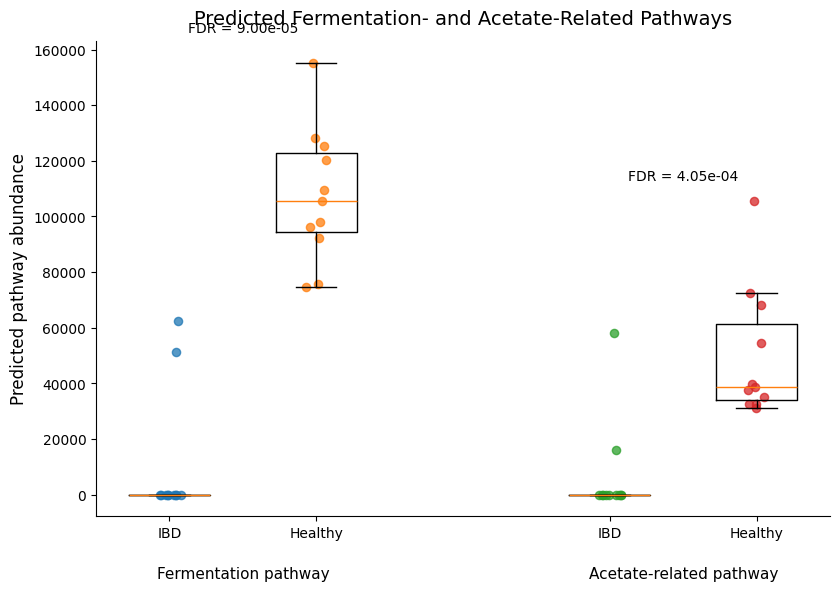

Final figure saved:
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.png
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load pathway abundance data
pathway_file = "/content/drive/MyDrive/Supplementary_Table_S8_PICRUSt2_Pathway_Abundance.csv"
pathways = pd.read_csv(pathway_file)

# Convert to sample × pathway format
pathway_df = pathways.set_index("pathway").T.copy()
pathway_df.index.name = "Sample"
pathway_df = pathway_df.reset_index()

# Assign groups
pathway_df["Group"] = pathway_df["Sample"].apply(
    lambda x: "IBD" if "Disease" in x else "Healthy"
)

selected_pathways = [
    "FERMENTATION-PWY",
    "METH-ACETATE-PWY"
]

labels = [
    "Fermentation pathway",
    "Acetate-related pathway"
]

# FDR values from Step 18
fdr_values = {
    "FERMENTATION-PWY": 0.000090,
    "METH-ACETATE-PWY": 0.000405
}

fig, ax = plt.subplots(figsize=(8.5, 6))

rng = np.random.default_rng(42)

for i, (pathway, label) in enumerate(zip(selected_pathways, labels)):

    ibd_values = pathway_df.loc[
        pathway_df["Group"] == "IBD", pathway
    ].astype(float).values

    healthy_values = pathway_df.loc[
        pathway_df["Group"] == "Healthy", pathway
    ].astype(float).values

    positions = [i * 3, i * 3 + 1]

    # Boxplots
    ax.boxplot(
        [ibd_values, healthy_values],
        positions=positions,
        widths=0.55,
        showfliers=False
    )

    # Individual observations
    for pos, values in zip(positions, [ibd_values, healthy_values]):

        jitter = rng.uniform(-0.08, 0.08, len(values))

        ax.scatter(
            pos + jitter,
            values,
            s=35,
            alpha=0.75
        )

    # FDR annotation
    ymax = max(
        np.max(ibd_values),
        np.max(healthy_values)
    )

    ax.text(
        np.mean(positions),
        ymax * 1.07,
        f"FDR = {fdr_values[pathway]:.2e}",
        ha="center",
        fontsize=10
    )

# X-axis
ax.set_xticks([0, 1, 3, 4])

ax.set_xticklabels([
    "IBD",
    "Healthy",
    "IBD",
    "Healthy"
], fontsize=10)

ax.set_ylabel(
    "Predicted pathway abundance",
    fontsize=12
)

ax.set_title(
    "Predicted Fermentation- and Acetate-Related Pathways",
    fontsize=14,
    pad=12
)

# Pathway labels above x-axis groups
ax.text(
    0.5, -0.13,
    "Fermentation pathway",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=11
)

ax.text(
    3.5, -0.13,
    "Acetate-related pathway",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=11
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save publication-quality files
png_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.png"
pdf_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.pdf"

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Final figure saved:")
print(png_path)
print(pdf_path)

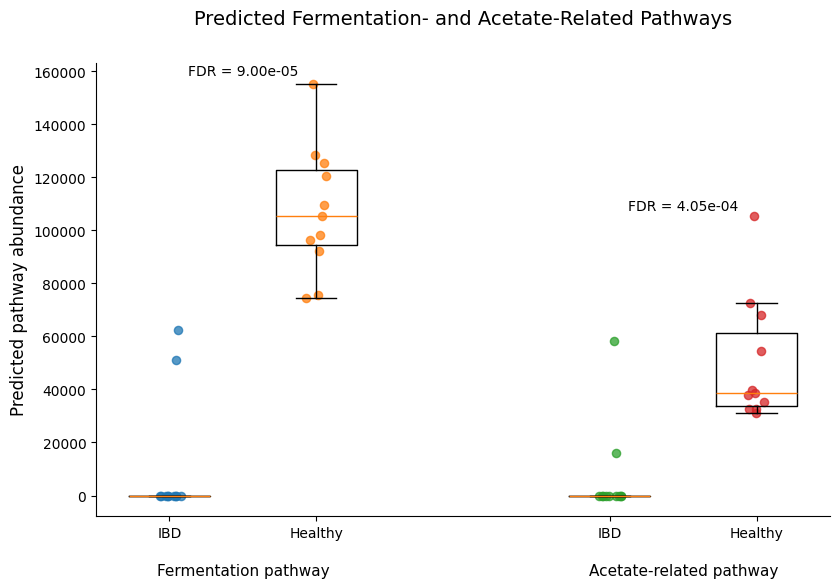

Final figure saved successfully:
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.png
/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load PICRUSt2 pathway abundance data
pathway_file = "/content/drive/MyDrive/Supplementary_Table_S8_PICRUSt2_Pathway_Abundance.csv"
pathways = pd.read_csv(pathway_file)

# Convert to sample × pathway format
pathway_df = pathways.set_index("pathway").T.copy()
pathway_df.index.name = "Sample"
pathway_df = pathway_df.reset_index()

# Assign groups
pathway_df["Group"] = pathway_df["Sample"].apply(
    lambda x: "IBD" if "Disease" in x else "Healthy"
)

# Pathways to plot
selected_pathways = [
    "FERMENTATION-PWY",
    "METH-ACETATE-PWY"
]

# Display labels
labels = [
    "Fermentation pathway",
    "Acetate-related pathway"
]

# FDR values
fdr_values = {
    "FERMENTATION-PWY": 0.000090,
    "METH-ACETATE-PWY": 0.000405
}

# Create figure
fig, ax = plt.subplots(figsize=(8.5, 6))

rng = np.random.default_rng(42)

for i, (pathway, label) in enumerate(zip(selected_pathways, labels)):

    # Get IBD values
    ibd_values = pathway_df.loc[
        pathway_df["Group"] == "IBD", pathway
    ].astype(float).values

    # Get Healthy values
    healthy_values = pathway_df.loc[
        pathway_df["Group"] == "Healthy", pathway
    ].astype(float).values

    positions = [i * 3, i * 3 + 1]

    # Boxplots
    ax.boxplot(
        [ibd_values, healthy_values],
        positions=positions,
        widths=0.55,
        showfliers=False
    )

    # Individual sample points
    for pos, values in zip(
        positions,
        [ibd_values, healthy_values]
    ):

        jitter = rng.uniform(
            -0.08, 0.08, len(values)
        )

        ax.scatter(
            pos + jitter,
            values,
            s=35,
            alpha=0.75
        )

    # FDR annotation
    ymax = max(
        np.max(ibd_values),
        np.max(healthy_values)
    )

    ax.text(
        np.mean(positions),
        ymax * 1.02,
        f"FDR = {fdr_values[pathway]:.2e}",
        ha="center",
        fontsize=10
    )

# X-axis labels
ax.set_xticks([0, 1, 3, 4])

ax.set_xticklabels(
    ["IBD", "Healthy", "IBD", "Healthy"],
    fontsize=10
)

# Y-axis
ax.set_ylabel(
    "Predicted pathway abundance",
    fontsize=12
)

# Title — increased padding to prevent overlap
ax.set_title(
    "Predicted Fermentation- and Acetate-Related Pathways",
    fontsize=14,
    pad=28
)

# Pathway labels
ax.text(
    0.5,
    -0.13,
    "Fermentation pathway",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=11
)

ax.text(
    3.5,
    -0.13,
    "Acetate-related pathway",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=11
)

# Clean publication-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save final publication-quality files
png_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.png"
pdf_path = "/content/drive/MyDrive/Step18_SCFA_Related_Pathway_Comparison_Final.pdf"

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Final figure saved successfully:")
print(png_path)
print(pdf_path)

In [ ]:
import pandas as pd

# Load Cytoscape NetworkAnalyzer results
df14 = pd.read_csv("/content/drive/MyDrive/step14 .csv")

# Create final summary
summary = []

# ---- Hub pathways ----
pathways = df14[df14["Category"] == "Pathway"].copy()
pathways = pathways.sort_values("Degree", ascending=False)

for _, row in pathways.iterrows():
    if row["Degree"] == pathways["Degree"].max():
        status = "Hub pathway – strongest connectivity"
    else:
        status = "Hub pathway – second highest connectivity"

    summary.append({
        "Node": row["name"],
        "Category": row["Category"],
        "Degree": row["Degree"],
        "Betweenness_Centrality": row["BetweennessCentrality"],
        "Closeness_Centrality": row["ClosenessCentrality"],
        "ML_Importance": row["ML_Importance"],
        "Hub_Status": status,
        "Interpretation": (
            "Most highly connected pathway in the biomarker-focused network."
            if row["Degree"] == pathways["Degree"].max()
            else
            "Second most highly connected pathway in the biomarker-focused network."
        )
    })

# ---- Candidate biomarkers ----
candidate = df14[df14["Category"] == "Candidate biomarker"].copy()

for _, row in candidate.iterrows():

    if row["Degree"] == 2:
        status = "High-connectivity candidate biomarker"
        interpretation = (
            "Candidate biomarker with the highest network connectivity "
            "among connected candidate biomarkers."
        )
    else:
        status = "Connected candidate biomarker"
        interpretation = (
            "Candidate biomarker connected to one significant pathway."
        )

    summary.append({
        "Node": row["name"],
        "Category": row["Category"],
        "Degree": row["Degree"],
        "Betweenness_Centrality": row["BetweennessCentrality"],
        "Closeness_Centrality": row["ClosenessCentrality"],
        "ML_Importance": row["ML_Importance"],
        "Hub_Status": status,
        "Interpretation": interpretation
    })

# ---- Save final summary ----
hub_summary = pd.DataFrame(summary)

output_path = "/content/drive/MyDrive/Step14_Network_Hub_Analysis_Summary.csv"
hub_summary.to_csv(output_path, index=False)

print("Step 14 summary created successfully!")
print()
print(hub_summary.to_string(index=False))
print()
print("Saved to:", output_path)

Step 14 summary created successfully!

                      Node            Category  Degree  Betweenness_Centrality  Closeness_Centrality  ML_Importance                                Hub_Status                                                                                  Interpretation
          LPS biosynthesis             Pathway      37                0.534146              0.854167            NaN      Hub pathway – strongest connectivity                                 Most highly connected pathway in the biomarker-focused network.
Peptidoglycan biosynthesis             Pathway      35                0.445122              0.788462            NaN Hub pathway – second highest connectivity                          Second most highly connected pathway in the biomarker-focused network.
                Sellimonas Candidate biomarker       1                0.000000              0.445652       0.068699             Connected candidate biomarker                                       Can

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Filtered_genus_abundance_ML.csv"))
print(os.path.exists("/content/drive/MyDrive/Supplementary_Table_S10_DESeq2_Significant_Genera.csv"))

True
True


In [ ]:
import pandas as pd

# Path to the filtered genus abundance matrix
file_path = "/content/drive/MyDrive/Filtered_genus_abundance_ML.csv"

# Load the dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (22, 70)


,Sample,Acidaminococcus,Acutalibacter,Adlercreutzia,Akkermansia,Alistipes,Anaerobutyricum,Anaerocolumna,Anaerostipes,Aristaeella,...,Segatella,Sellimonas,Sodalis,Solibaculum,Spirosoma,Streptococcus,Thomasclavelia,Veillonella,Vescimonas,Group
0,Sample_1,0.0,0.0,0.0,0.01162,0.00506,0.01175,0.0,0.00538,0.00059,...,0.35269,0.0,0.00069,0.02229,0.00172,0.00842,0.0,0.0,0.01875,IBD
1,Sample_2,0.0,0.0,0.0,0.00000,0.00138,0.00133,0.0,0.00071,0.00030,...,0.51980,0.0,0.00516,0.00694,0.00253,0.00000,0.0,0.0,0.00700,IBD
2,Sample_3,0.0,0.0,0.0,0.00000,0.00156,0.00112,0.0,0.00098,0.00021,...,0.51668,0.0,0.00492,0.00773,0.00265,0.00000,0.0,0.0,0.00618,IBD
3,Sample_4,0.0,0.0,0.0,0.00000,0.00116,0.00169,0.0,0.00304,0.00033,...,0.42948,0.0,0.00120,0.00228,0.00087,0.00000,0.0,0.0,0.00294,IBD
4,Sample_5,0.0,0.0,0.0,0.00000,0.00156,0.00000,0.0,0.00360,0.00000,...,0.41959,0.0,0.00673,0.00219,0.00280,0.00000,0.0,0.0,0.00288,IBD


In [ ]:
# Check sample identifiers and disease groups

print("Sample groups:")
print(df["Group"].value_counts())

print("\nLast 5 columns:")
print(df.columns[-5:].tolist())

print("\nGroup values:")
print(df["Group"].unique())

Sample groups:
Group
IBD        11
Healthy    11
Name: count, dtype: int64

Last 5 columns:
['Streptococcus', 'Thomasclavelia', 'Veillonella', 'Vescimonas', 'Group']

Group values:
['IBD' 'Healthy']


In [ ]:
import pandas as pd
import numpy as np

print("Imports successful")

Imports successful


In [ ]:
de_results_path = "/content/drive/MyDrive/Supplementary_Table_S10_DESeq2_Significant_Genera.csv"

de_results = pd.read_csv(de_results_path)

print("DESeq2 table shape:", de_results.shape)
print("\nColumns:")
print(de_results.columns.tolist())

display(de_results.head())

DESeq2 table shape: (59, 7)

Columns:
['Unnamed: 0', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ASF356,18.772801,-6.460346,1.219338,-5.298241,1.170000e-07,8.120000e-07
1,Acidaminococcus,194.384719,-24.954747,2.342706,-10.652106,1.700000e-26,1.010000e-24
2,Acutalibacter,56.132698,-2.913030,1.422805,-2.047385,4.062027e-02,8.578133e-02
3,Anaerostipes,347.952052,-3.768467,1.528585,-2.465330,1.368872e-02,3.885601e-02
4,Anaerotignum,101.578841,-8.878927,1.604274,-5.534547,3.120000e-08,2.630000e-07


In [ ]:
# Step 9A — Combine DESeq2 significant taxa with RF importance

# Load RF feature importance
rf_path = "/content/drive/MyDrive/RF_feature_importance.csv"
rf_importance = pd.read_csv(rf_path)

# Rename DESeq2 genus column
de_results = de_results.rename(columns={"Unnamed: 0": "Genus"})

# Clean genus names
de_results["Genus"] = de_results["Genus"].astype(str).str.strip()
rf_importance["Genus"] = rf_importance["Genus"].astype(str).str.strip()

# Define ML-important taxa as Top 10 RF-ranked genera
ml_important = rf_importance.head(10)["Genus"].tolist()

# Create combined candidate table
candidate_table = de_results[["Genus", "log2FoldChange", "pvalue", "padj"]].copy()

candidate_table["DESeq2_significant"] = "Yes"
candidate_table["ML_important"] = candidate_table["Genus"].isin(ml_important).map(
    {True: "Yes", False: "No"}
)

# Add RF importance
candidate_table = candidate_table.merge(
    rf_importance[["Genus", "Rank", "Mean_Importance"]],
    on="Genus",
    how="left"
)

# Sort: ML-important first, then by DESeq2 adjusted p-value
candidate_table = candidate_table.sort_values(
    by=["ML_important", "padj"],
    ascending=[False, True]
).reset_index(drop=True)

print("DESeq2 significant genera:", len(de_results))
print("RF ML-important genera:", len(ml_important))
print("Overlap between DESeq2 and RF:",
      (candidate_table["ML_important"] == "Yes").sum())

display(candidate_table.head(20))

DESeq2 significant genera: 59
RF ML-important genera: 10
Overlap between DESeq2 and RF: 5


,Genus,log2FoldChange,pvalue,padj,DESeq2_significant,ML_important,Rank,Mean_Importance
0,Segatella,24.536094,9.370000e-17,1.840000e-15,Yes,Yes,3.0,0.073757
1,Sellimonas,-8.120743,6.970000e-07,4.330000e-06,Yes,Yes,4.0,0.068699
2,Flavonifractor,-5.803912,5.500000e-05,2.821240e-04,Yes,Yes,9.0,0.035823
3,Paludicola,-6.098071,6.035052e-03,2.034675e-02,Yes,Yes,6.0,0.050991
4,Bifidobacterium,-4.481723,7.562215e-03,2.411734e-02,Yes,Yes,7.0,0.048550
5,Dialister,-26.672620,1.390000e-29,1.630000e-27,Yes,No,NaN,NaN
6,Acidaminococcus,-24.954747,1.700000e-26,1.010000e-24,Yes,No,33.0,0.006562
7,Massiliprevotella,-25.592542,7.530000e-23,2.960000e-21,Yes,No,NaN,NaN
8,Macellibacteroides,-23.952929,1.320000e-21,3.910000e-20,Yes,No,NaN,NaN
9,Pseudobutyrivibrio,-12.576856,1.720000e-20,4.070000e-19,Yes,No,NaN,NaN


### 5.1 Log Transformation

The filtered genus-level relative abundance features were transformed using
the natural logarithm of one plus the abundance value (`log1p`).

This transformation was applied only to microbial genus features. Sample
identifiers and disease-status labels were retained separately and were not
transformed.


In [ ]:
import numpy as np
import pandas as pd

print("NumPy and Pandas loaded successfully.")

NumPy and Pandas loaded successfully.


In [ ]:
# Step 9B — Check functional/pathway associations of ML-important genera

correlation_path = "/content/drive/MyDrive/Supplementary_Table_S12_Significant_Correlations_FDR.csv"

correlations = pd.read_csv(correlation_path)

# Our 5 DESeq2 + RF overlapping genera
overlap_genera = [
    "Segatella",
    "Sellimonas",
    "Flavonifractor",
    "Paludicola",
    "Bifidobacterium"
]

# Clean genus names
correlations["Genus"] = correlations["Genus"].astype(str).str.strip()

# Find functional associations for these genera
functional_candidates = correlations[
    correlations["Genus"].isin(overlap_genera)
].copy()

print("Functional associations found:", len(functional_candidates))
print("\nGenera with functional associations:")

display(
    functional_candidates[
        ["Genus", "Pathway", "Rho", "Pvalue", "FDR"]
    ].sort_values(["Genus", "FDR"])
)

Functional associations found: 6

Genera with functional associations:


,Genus,Pathway,Rho,Pvalue,FDR
21,Bifidobacterium,LPSSYN-PWY,0.880649,6.410000e-08,2.200000e-06
22,Bifidobacterium,PEPTIDOGLYCANSYN-PWY,0.869170,1.530000e-07,4.500000e-06
57,Flavonifractor,PEPTIDOGLYCANSYN-PWY,0.908899,4.860000e-09,4.000000e-07
56,Flavonifractor,LPSSYN-PWY,0.795455,9.640000e-06,9.030000e-05
100,Sellimonas,PEPTIDOGLYCANSYN-PWY,0.753875,5.080000e-05,3.535760e-04
99,Sellimonas,LPSSYN-PWY,0.647281,1.128813e-03,5.813385e-03


In [ ]:
# Step 9C — Create integrated biomarker candidate table

# Start with the 59 DESeq2-significant genera
integrated_candidates = candidate_table.copy()

# Mark functional association
functional_genera = set(functional_candidates["Genus"].unique())

integrated_candidates["Functional_association"] = (
    integrated_candidates["Genus"]
    .isin(functional_genera)
    .map({True: "Yes", False: "No"})
)

# Evidence score
integrated_candidates["Evidence_score"] = (
    (integrated_candidates["DESeq2_significant"] == "Yes").astype(int)
    + (integrated_candidates["ML_important"] == "Yes").astype(int)
    + (integrated_candidates["Functional_association"] == "Yes").astype(int)
)

# Priority based on combined evidence
integrated_candidates["Priority"] = integrated_candidates["Evidence_score"].map({
    3: "High",
    2: "Moderate",
    1: "Low"
})

# Put strongest candidates first
integrated_candidates = integrated_candidates.sort_values(
    by=["Evidence_score", "Mean_Importance"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

print("Integrated candidate biomarker table created.")
print("\nPriority distribution:")
print(integrated_candidates["Priority"].value_counts())

display(integrated_candidates.head(20))

Integrated candidate biomarker table created.

Priority distribution:
Priority
Low         54
High         3
Moderate     2
Name: count, dtype: int64


,Genus,log2FoldChange,pvalue,padj,DESeq2_significant,ML_important,Rank,Mean_Importance,Functional_association,Evidence_score,Priority
0,Sellimonas,-8.120743,6.970000e-07,4.330000e-06,Yes,Yes,4.0,0.068699,Yes,3,High
1,Bifidobacterium,-4.481723,7.562215e-03,2.411734e-02,Yes,Yes,7.0,0.048550,Yes,3,High
2,Flavonifractor,-5.803912,5.500000e-05,2.821240e-04,Yes,Yes,9.0,0.035823,Yes,3,High
3,Segatella,24.536094,9.370000e-17,1.840000e-15,Yes,Yes,3.0,0.073757,No,2,Moderate
4,Paludicola,-6.098071,6.035052e-03,2.034675e-02,Yes,Yes,6.0,0.050991,No,2,Moderate
5,Acutalibacter,-2.913030,4.062027e-02,8.578133e-02,Yes,No,12.0,0.028810,No,1,Low
6,Bacteroides,-4.336166,1.503106e-02,4.031058e-02,Yes,No,15.0,0.020916,No,1,Low
7,Holdemania,-4.946991,2.215630e-04,1.080363e-03,Yes,No,22.0,0.010624,No,1,Low
8,Ruminococcus,-3.596602,2.752827e-02,6.246800e-02,Yes,No,23.0,0.010070,No,1,Low
9,Hungatella,-3.712005,4.047091e-02,8.578133e-02,Yes,No,26.0,0.009018,No,1,Low


In [ ]:
# Step 9D — Save integrated biomarker candidate table

output_path = "/content/drive/MyDrive/Integrated_Biomarker_Candidate_Table.csv"

integrated_candidates.to_csv(output_path, index=False)

# Verify saved file
saved_table = pd.read_csv(output_path)

print("File saved successfully.")
print("Shape:", saved_table.shape)
print("Location:", output_path)

print("\nPriority distribution:")
print(saved_table["Priority"].value_counts())

print("\nHigh-priority candidates:")
display(
    saved_table[saved_table["Priority"] == "High"][
        [
            "Genus",
            "log2FoldChange",
            "padj",
            "Rank",
            "Mean_Importance",
            "Functional_association",
            "Evidence_score",
            "Priority"
        ]
    ]
)

File saved successfully.
Shape: (59, 11)
Location: /content/drive/MyDrive/Integrated_Biomarker_Candidate_Table.csv

Priority distribution:
Priority
Low         54
High         3
Moderate     2
Name: count, dtype: int64

High-priority candidates:


,Genus,log2FoldChange,padj,Rank,Mean_Importance,Functional_association,Evidence_score,Priority
0,Sellimonas,-8.120743,0.000004,4.0,0.068699,Yes,3,High
1,Bifidobacterium,-4.481723,0.024117,7.0,0.048550,Yes,3,High
2,Flavonifractor,-5.803912,0.000282,9.0,0.035823,Yes,3,High


In [ ]:
# Step 9E — Create corrected candidate biomarker table
# DESeq2 significant taxa + RF ML-important taxa = candidate set

# 1. Get DESeq2 significant genera
de_genera = set(de_results["Genus"])

# 2. Get Top 10 RF-important genera
rf_genera = set(ml_important)

# 3. Union of both evidence sets
candidate_genera = sorted(de_genera.union(rf_genera))

print("DESeq2 genera:", len(de_genera))
print("RF-important genera:", len(rf_genera))
print("Unique candidate genera:", len(candidate_genera))

# 4. Create candidate table
corrected_candidates = pd.DataFrame({"Genus": candidate_genera})

# DESeq2 evidence
corrected_candidates["DESeq2_significant"] = (
    corrected_candidates["Genus"]
    .isin(de_genera)
    .map({True: "Yes", False: "No"})
)

# RF evidence + importance
corrected_candidates = corrected_candidates.merge(
    rf_importance[["Genus", "Rank", "Mean_Importance"]],
    on="Genus",
    how="left"
)

corrected_candidates["ML_important"] = (
    corrected_candidates["Genus"]
    .isin(rf_genera)
    .map({True: "Yes", False: "No"})
)

# Functional association
corrected_candidates["Functional_association"] = (
    corrected_candidates["Genus"]
    .isin(functional_genera)
    .map({True: "Yes", False: "No"})
)

# DESeq2 statistics
corrected_candidates = corrected_candidates.merge(
    de_results[["Genus", "log2FoldChange", "pvalue", "padj"]],
    on="Genus",
    how="left"
)

# Evidence score
corrected_candidates["Evidence_score"] = (
    (corrected_candidates["DESeq2_significant"] == "Yes").astype(int)
    + (corrected_candidates["ML_important"] == "Yes").astype(int)
    + (corrected_candidates["Functional_association"] == "Yes").astype(int)
)

# Priority
corrected_candidates["Priority"] = corrected_candidates["Evidence_score"].map({
    3: "High",
    2: "Moderate",
    1: "Low"
})

# Sort strongest candidates first
corrected_candidates = corrected_candidates.sort_values(
    by=["Evidence_score", "Mean_Importance"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

print("\nPriority distribution:")
print(corrected_candidates["Priority"].value_counts())

display(corrected_candidates.head(20))

DESeq2 genera: 59
RF-important genera: 10
Unique candidate genera: 64

Priority distribution:
Priority
Low         59
High         3
Moderate     2
Name: count, dtype: int64


,Genus,DESeq2_significant,Rank,Mean_Importance,ML_important,Functional_association,log2FoldChange,pvalue,padj,Evidence_score,Priority
0,Sellimonas,Yes,4.0,0.068699,Yes,Yes,-8.120743,6.970000e-07,4.330000e-06,3,High
1,Bifidobacterium,Yes,7.0,0.048550,Yes,Yes,-4.481723,7.562215e-03,2.411734e-02,3,High
2,Flavonifractor,Yes,9.0,0.035823,Yes,Yes,-5.803912,5.500000e-05,2.821240e-04,3,High
3,Segatella,Yes,3.0,0.073757,Yes,No,24.536094,9.370000e-17,1.840000e-15,2,Moderate
4,Paludicola,Yes,6.0,0.050991,Yes,No,-6.098071,6.035052e-03,2.034675e-02,2,Moderate
5,Sodalis,No,1.0,0.095612,Yes,No,NaN,NaN,NaN,1,Low
6,Enterococcus,No,2.0,0.087943,Yes,No,NaN,NaN,NaN,1,Low
7,Adlercreutzia,No,5.0,0.053133,Yes,No,NaN,NaN,NaN,1,Low
8,Anaerocolumna,No,8.0,0.044398,Yes,No,NaN,NaN,NaN,1,Low
9,Mediterraneibacter,No,10.0,0.031800,Yes,No,NaN,NaN,NaN,1,Low


In [ ]:
# Save corrected Step 9 candidate table

final_path = "/content/drive/MyDrive/Step9_Integrated_Biomarker_Candidate_Table.csv"

corrected_candidates.to_csv(final_path, index=False)

print("Step 9 final table saved successfully.")
print("Shape:", corrected_candidates.shape)
print("Saved at:", final_path)

Step 9 final table saved successfully.
Shape: (64, 11)
Saved at: /content/drive/MyDrive/Step9_Integrated_Biomarker_Candidate_Table.csv


In [ ]:
# ============================================================
# Step 10 — ROC-AUC Analysis
# Step 10.1 — Load abundance data and candidate biomarker table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

# File paths
abundance_path = "/content/drive/MyDrive/Filtered_genus_abundance_ML.csv"
candidate_path = "/content/drive/MyDrive/Step9_Integrated_Biomarker_Candidate_Table.csv"

# Load datasets
abundance_df = pd.read_csv(abundance_path)
candidate_df = pd.read_csv(candidate_path)

# Display basic information
print("Abundance dataset shape:", abundance_df.shape)
print("Candidate table shape:", candidate_df.shape)

print("\nAbundance dataset columns:")
print(abundance_df.columns.tolist())

print("\nCandidate table columns:")
print(candidate_df.columns.tolist())

Abundance dataset shape: (22, 70)
Candidate table shape: (64, 11)

Abundance dataset columns:
['Sample', 'Acidaminococcus', 'Acutalibacter', 'Adlercreutzia', 'Akkermansia', 'Alistipes', 'Anaerobutyricum', 'Anaerocolumna', 'Anaerostipes', 'Aristaeella', 'Aureibaculum', 'Bacteroides', 'Barnesiella', 'Bengtsoniella', 'Bifidobacterium', 'Blautia', 'Butyricimonas', 'Chakrabartyella', 'Chordicoccus', 'Christensenella', 'Clostridium', 'Coprobacter', 'Coprococcus', 'Dorea', 'Duodenibacillus', 'Eisenbergiella', 'Enterobacter', 'Enterococcus', 'Escherichia', 'Eubacterium', 'Faecalibacillus', 'Faecalibacterium', 'Flavonifractor', 'Flintibacter', 'Gordonibacter', 'Haemophilus', 'Holdemania', 'Hoylesella', 'Hungatella', 'Intestinimonas', 'Kiritimatiella', 'Lachnospira', 'Lawsonibacter', 'Ligilactobacillus', 'Mediterraneibacter', 'Megamonas', 'Odoribacter', 'Paenibacillus', 'Paludicola', 'Parabacteroides', 'Paraprevotella', 'Phascolarctobacterium', 'Phocaeicola', 'Prevotella', 'Pseudoflavonifractor'

In [ ]:
# ============================================================
# Step 10.2 — Define ROC candidate biomarker set
# ============================================================

# Candidate genera identified in Step 9
candidate_genera = candidate_df["Genus"].dropna().unique().tolist()

# Check which candidates are present in the abundance matrix
available_candidates = [
    genus for genus in candidate_genera
    if genus in abundance_df.columns
]

missing_candidates = [
    genus for genus in candidate_genera
    if genus not in abundance_df.columns
]

print("Total candidate genera from Step 9:", len(candidate_genera))
print("Candidates available in abundance matrix:", len(available_candidates))
print("Candidates missing from abundance matrix:", len(missing_candidates))

if missing_candidates:
    print("\nMissing candidates:")
    print(missing_candidates)

print("\nCandidate genera available for ROC analysis:")
print(available_candidates)

Total candidate genera from Step 9: 64
Candidates available in abundance matrix: 27
Candidates missing from abundance matrix: 37

Missing candidates:
['ASF356', 'Anaerotignum', 'Anaerotruncus', 'CAG-352', 'Candidatus Soleaferrea', 'Colidextribacter', 'Coprobacillus', 'Coriobacteriaceae UCG-003', 'DTU089', 'Dialister', 'Eggerthella', 'Enterocloster', 'Enteroscipio', 'Escherichia-Shigella', 'Faecalicatena', 'Fusicatenibacter', 'Klebsiella', 'Lachnospiraceae FE2018 group', 'Lachnospiraceae ND3007 group', 'Lachnospiraceae UCG-003', 'Lachnospiraceae UCG-010', 'Macellibacteroides', 'Massiliprevotella', 'Monoglobus', 'Oscillospira', 'Paeniclostridium', 'Phocea', 'Pseudobutyrivibrio', 'Roseburia', 'Subdoligranulum', 'Sutterella', 'UCG-005', 'Unclassified', '[Clostridium] innocuum group', '[Eubacterium] eligens group', '[Eubacterium] ventriosum group', '[Ruminococcus] gnavus group']

Candidate genera available for ROC analysis:
['Sellimonas', 'Bifidobacterium', 'Flavonifractor', 'Segatella', 'P

In [ ]:
# ============================================================
# Step 10.3 — Individual ROC-AUC Analysis
# ============================================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Disease labels
y_true = abundance_df["Group"].map({
    "Healthy": 0,
    "IBD": 1
}).values

roc_results = []

for genus in available_candidates:

    # Genus abundance
    x = abundance_df[genus].values

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, x)

    # AUC
    auc_value = roc_auc_score(y_true, x)

    # Youden's J statistic
    youden_j = tpr - fpr

    # Optimal threshold
    best_index = np.argmax(youden_j)

    optimal_threshold = thresholds[best_index]
    sensitivity = tpr[best_index]
    specificity = 1 - fpr[best_index]

    roc_results.append({
        "Genus": genus,
        "AUC": auc_value,
        "Optimal_Threshold": optimal_threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

# Create results table
roc_results_df = pd.DataFrame(roc_results)

# Sort by AUC
roc_results_df = roc_results_df.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

# Add rank
roc_results_df.insert(
    0,
    "ROC_Rank",
    range(1, len(roc_results_df) + 1)
)

# Display results
print("Individual ROC-AUC analysis completed.")
print("Number of candidate genera tested:", len(roc_results_df))

roc_results_df

Individual ROC-AUC analysis completed.
Number of candidate genera tested: 27


,ROC_Rank,Genus,AUC,Optimal_Threshold,Sensitivity,Specificity
0,1,Enterococcus,1.000000,0.00480,1.000000,1.000000
1,2,Sodalis,1.000000,0.00066,1.000000,1.000000
2,3,Segatella,1.000000,0.00029,1.000000,1.000000
3,4,Coprococcus,0.772727,0.00468,0.727273,0.727273
4,5,Ruminococcus,0.669421,0.01013,1.000000,0.545455
5,6,Faecalibacterium,0.454545,0.10349,0.545455,0.636364
6,7,Lachnospira,0.446281,0.00690,0.818182,0.363636
7,8,Thomasclavelia,0.359504,0.01232,0.090909,1.000000
8,9,Ligilactobacillus,0.330579,inf,0.000000,1.000000
9,10,Coprobacter,0.309917,inf,0.000000,1.000000


In [ ]:
# ============================================================
# Step 10.3 — Direction-Aware Individual ROC-AUC Analysis
# ============================================================

roc_results_corrected = []

for genus in available_candidates:

    # Genus abundance
    x = abundance_df[genus].values

    # Raw ROC: higher abundance -> IBD
    fpr_high, tpr_high, thresholds_high = roc_curve(y_true, x)
    auc_high = roc_auc_score(y_true, x)

    # ROC using inverse direction: lower abundance -> IBD
    fpr_low, tpr_low, thresholds_low = roc_curve(y_true, -x)
    auc_low = roc_auc_score(y_true, -x)

    # Select biologically appropriate direction
    if auc_high >= auc_low:
        direction = "Higher abundance → IBD"
        auc_value = auc_high
        fpr = fpr_high
        tpr = tpr_high
        thresholds = thresholds_high
        predictor = x
    else:
        direction = "Lower abundance → IBD"
        auc_value = auc_low
        fpr = fpr_low
        tpr = tpr_low
        thresholds = thresholds_low
        predictor = -x

    # Youden's J statistic
    youden_j = tpr - fpr

    # Optimal threshold
    best_index = np.argmax(youden_j)

    optimal_threshold = thresholds[best_index]
    sensitivity = tpr[best_index]
    specificity = 1 - fpr[best_index]

    roc_results_corrected.append({
        "Genus": genus,
        "Direction": direction,
        "AUC": auc_value,
        "Optimal_Threshold": optimal_threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

# Create results table
roc_results_df = pd.DataFrame(roc_results_corrected)

# Rank by direction-aware AUC
roc_results_df = roc_results_df.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

roc_results_df.insert(
    0,
    "ROC_Rank",
    range(1, len(roc_results_df) + 1)
)

print("Direction-aware ROC-AUC analysis completed.")
print("Candidate genera tested:", len(roc_results_df))

roc_results_df

Direction-aware ROC-AUC analysis completed.
Candidate genera tested: 27


,ROC_Rank,Genus,Direction,AUC,Optimal_Threshold,Sensitivity,Specificity
0,1,Enterococcus,Higher abundance → IBD,1.000000,0.00480,1.000000,1.000000
1,2,Sodalis,Higher abundance → IBD,1.000000,0.00066,1.000000,1.000000
2,3,Segatella,Higher abundance → IBD,1.000000,0.00029,1.000000,1.000000
3,4,Sellimonas,Lower abundance → IBD,0.991736,-0.00000,0.909091,1.000000
4,5,Paludicola,Lower abundance → IBD,0.983471,-0.00000,0.909091,1.000000
5,6,Bifidobacterium,Lower abundance → IBD,0.966942,-0.01540,0.909091,0.909091
6,7,Adlercreutzia,Lower abundance → IBD,0.954545,-0.00000,1.000000,0.909091
7,8,Anaerocolumna,Lower abundance → IBD,0.950413,-0.00013,1.000000,0.909091
8,9,Acutalibacter,Lower abundance → IBD,0.909091,-0.00000,1.000000,0.818182
9,10,Flavonifractor,Lower abundance → IBD,0.892562,-0.00046,0.818182,1.000000


In [ ]:
# ============================================================
# Step 10.4 — 95% Confidence Interval for ROC-AUC
# ============================================================

from sklearn.utils import resample

def bootstrap_auc_ci(y_true, predictor, n_bootstraps=2000, random_state=42):
    """
    Calculate bootstrap 95% confidence interval for ROC-AUC.
    """

    rng = np.random.RandomState(random_state)
    auc_values = []

    y_true = np.asarray(y_true)
    predictor = np.asarray(predictor)

    for _ in range(n_bootstraps):

        indices = rng.randint(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[indices]
        pred_boot = predictor[indices]

        # Skip bootstrap samples containing only one class
        if len(np.unique(y_boot)) < 2:
            continue

        auc_values.append(
            roc_auc_score(y_boot, pred_boot)
        )

    auc_values = np.array(auc_values)

    lower = np.percentile(auc_values, 2.5)
    upper = np.percentile(auc_values, 97.5)

    return lower, upper


# Calculate 95% CI for every candidate genus
ci_results = []

for genus in available_candidates:

    x = abundance_df[genus].values

    # Determine the better predictive direction
    auc_high = roc_auc_score(y_true, x)
    auc_low = roc_auc_score(y_true, -x)

    if auc_high >= auc_low:
        predictor = x
        direction = "Higher abundance → IBD"
        auc_value = auc_high
    else:
        predictor = -x
        direction = "Lower abundance → IBD"
        auc_value = auc_low

    # Bootstrap 95% CI
    ci_lower, ci_upper = bootstrap_auc_ci(
        y_true,
        predictor,
        n_bootstraps=2000,
        random_state=42
    )

    ci_results.append({
        "Genus": genus,
        "Direction": direction,
        "AUC": auc_value,
        "AUC_95CI_Lower": ci_lower,
        "AUC_95CI_Upper": ci_upper
    })


# Create CI table
auc_ci_df = pd.DataFrame(ci_results)

# Sort by AUC
auc_ci_df = auc_ci_df.sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

auc_ci_df.insert(
    0,
    "ROC_Rank",
    range(1, len(auc_ci_df) + 1)
)

print("Bootstrap 95% CI analysis completed.")
print("Number of genera analyzed:", len(auc_ci_df))

auc_ci_df

Bootstrap 95% CI analysis completed.
Number of genera analyzed: 27


,ROC_Rank,Genus,Direction,AUC,AUC_95CI_Lower,AUC_95CI_Upper
0,1,Enterococcus,Higher abundance → IBD,1.000000,1.000000,1.000000
1,2,Sodalis,Higher abundance → IBD,1.000000,1.000000,1.000000
2,3,Segatella,Higher abundance → IBD,1.000000,1.000000,1.000000
3,4,Sellimonas,Lower abundance → IBD,0.991736,0.950000,1.000000
4,5,Paludicola,Lower abundance → IBD,0.983471,0.923077,1.000000
5,6,Bifidobacterium,Lower abundance → IBD,0.966942,0.880342,1.000000
6,7,Adlercreutzia,Lower abundance → IBD,0.954545,0.850000,1.000000
7,8,Anaerocolumna,Lower abundance → IBD,0.950413,0.837500,1.000000
8,9,Acutalibacter,Lower abundance → IBD,0.909091,0.772727,1.000000
9,10,Flavonifractor,Lower abundance → IBD,0.892562,0.723214,1.000000


In [ ]:
# ============================================================
# Step 10.5 — Final Individual ROC Results Table
# ============================================================

# Merge ROC performance with bootstrap confidence intervals
roc_final_df = roc_results_df.merge(
    auc_ci_df[
        [
            "Genus",
            "AUC_95CI_Lower",
            "AUC_95CI_Upper"
        ]
    ],
    on="Genus",
    how="left"
)

# Reorder columns
roc_final_df = roc_final_df[
    [
        "ROC_Rank",
        "Genus",
        "Direction",
        "AUC",
        "AUC_95CI_Lower",
        "AUC_95CI_Upper",
        "Optimal_Threshold",
        "Sensitivity",
        "Specificity"
    ]
]

# Round numerical values for clean reporting
roc_final_df["AUC"] = roc_final_df["AUC"].round(4)
roc_final_df["AUC_95CI_Lower"] = roc_final_df["AUC_95CI_Lower"].round(4)
roc_final_df["AUC_95CI_Upper"] = roc_final_df["AUC_95CI_Upper"].round(4)
roc_final_df["Optimal_Threshold"] = roc_final_df["Optimal_Threshold"].round(6)
roc_final_df["Sensitivity"] = roc_final_df["Sensitivity"].round(4)
roc_final_df["Specificity"] = roc_final_df["Specificity"].round(4)

# Save to Google Drive
roc_results_path = "/content/drive/MyDrive/Step10_Individual_ROC_AUC_Results.csv"

roc_final_df.to_csv(
    roc_results_path,
    index=False
)

print("Step 10 individual ROC results saved successfully.")
print("Shape:", roc_final_df.shape)
print("Saved at:", roc_results_path)

roc_final_df

Step 10 individual ROC results saved successfully.
Shape: (27, 9)
Saved at: /content/drive/MyDrive/Step10_Individual_ROC_AUC_Results.csv


,ROC_Rank,Genus,Direction,AUC,AUC_95CI_Lower,AUC_95CI_Upper,Optimal_Threshold,Sensitivity,Specificity
0,1,Enterococcus,Higher abundance → IBD,1.0000,1.0000,1.0000,0.00480,1.0000,1.0000
1,2,Sodalis,Higher abundance → IBD,1.0000,1.0000,1.0000,0.00066,1.0000,1.0000
2,3,Segatella,Higher abundance → IBD,1.0000,1.0000,1.0000,0.00029,1.0000,1.0000
3,4,Sellimonas,Lower abundance → IBD,0.9917,0.9500,1.0000,-0.00000,0.9091,1.0000
4,5,Paludicola,Lower abundance → IBD,0.9835,0.9231,1.0000,-0.00000,0.9091,1.0000
5,6,Bifidobacterium,Lower abundance → IBD,0.9669,0.8803,1.0000,-0.01540,0.9091,0.9091
6,7,Adlercreutzia,Lower abundance → IBD,0.9545,0.8500,1.0000,-0.00000,1.0000,0.9091
7,8,Anaerocolumna,Lower abundance → IBD,0.9504,0.8375,1.0000,-0.00013,1.0000,0.9091
8,9,Acutalibacter,Lower abundance → IBD,0.9091,0.7727,1.0000,-0.00000,1.0000,0.8182
9,10,Flavonifractor,Lower abundance → IBD,0.8926,0.7232,1.0000,-0.00046,0.8182,1.0000


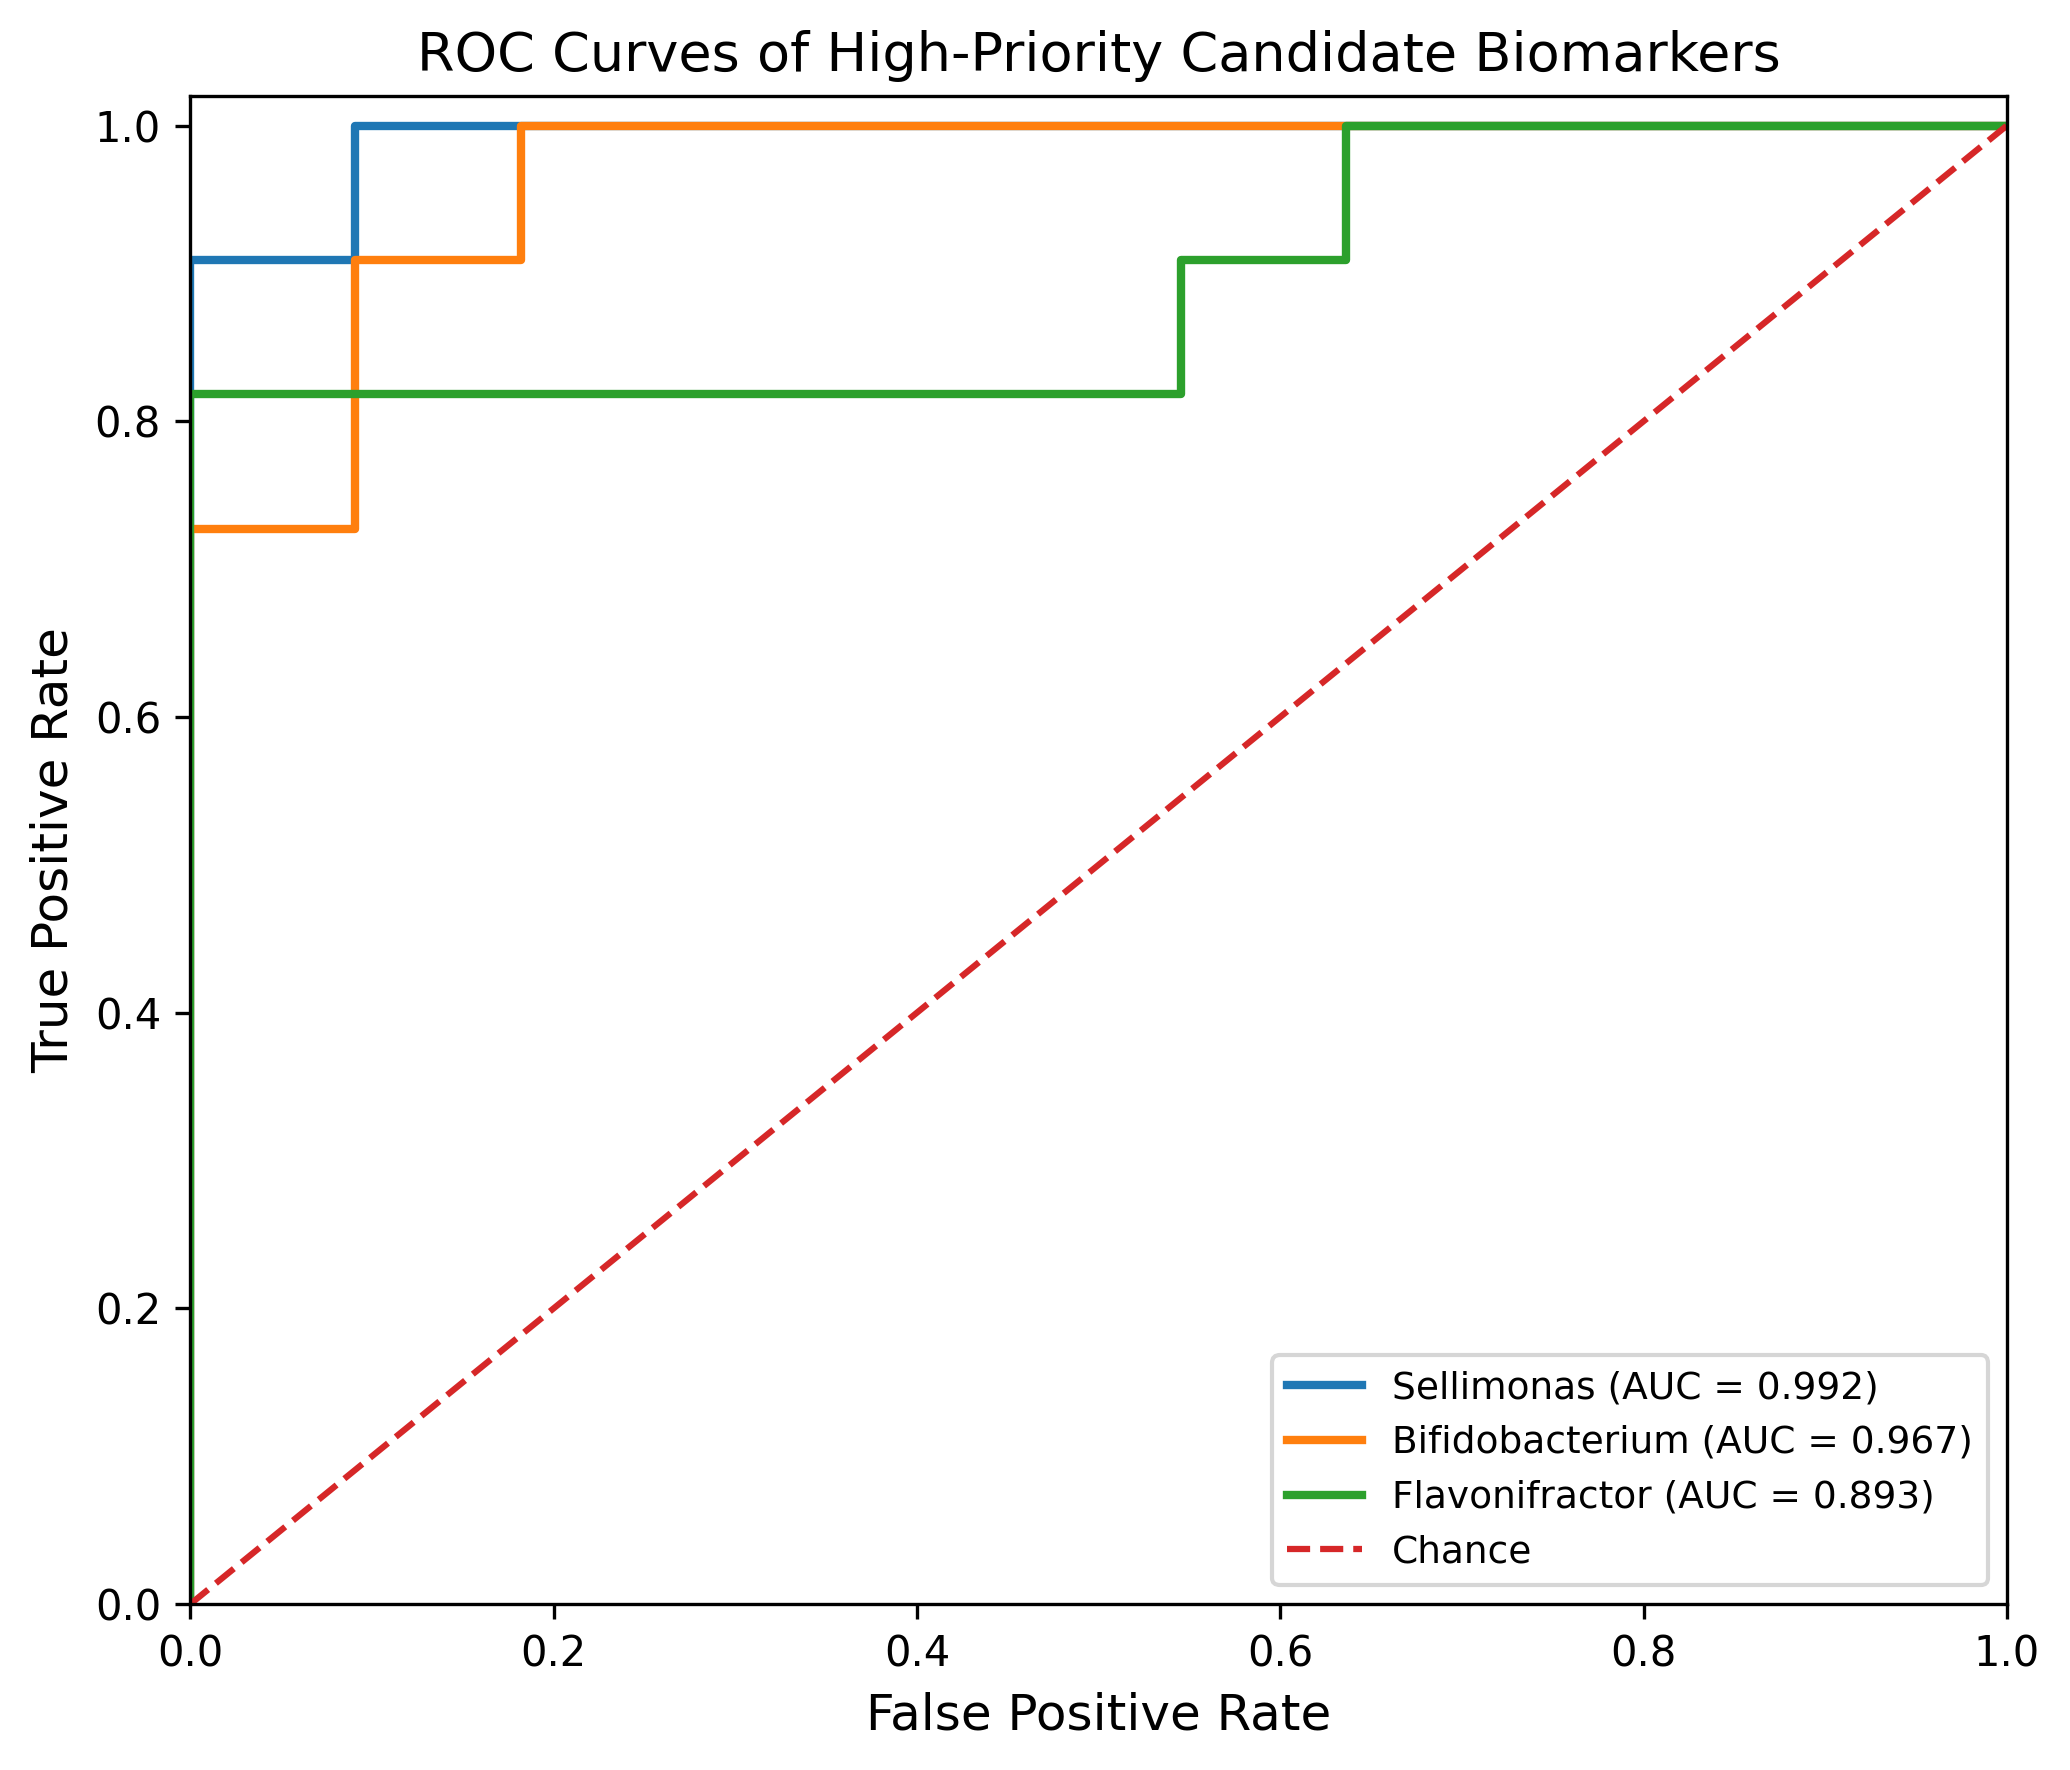

Publication-quality ROC figure saved successfully.
Saved at: /content/drive/MyDrive/Step10_ROC_Curves_High_Priority_Candidates.png


In [ ]:
# ============================================================
# Step 10.6 — Publication-Quality ROC Curves
# High-priority candidate biomarkers
# ============================================================

# High-priority candidates identified in Step 9
top_candidates = [
    "Sellimonas",
    "Bifidobacterium",
    "Flavonifractor"
]

# Create publication-quality ROC figure
plt.figure(figsize=(7, 6), dpi=300)

for genus in top_candidates:

    x = abundance_df[genus].values

    # Determine predictive direction
    auc_high = roc_auc_score(y_true, x)
    auc_low = roc_auc_score(y_true, -x)

    if auc_high >= auc_low:
        predictor = x
        direction = "higher"
        auc_value = auc_high
    else:
        predictor = -x
        direction = "lower"
        auc_value = auc_low

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, predictor)

    # Plot
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{genus} (AUC = {auc_value:.3f})"
    )

# Reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

# Figure formatting
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curves of High-Priority Candidate Biomarkers",
    fontsize=13
)

plt.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

# Save figure
roc_figure_path = (
    "/content/drive/MyDrive/"
    "Step10_ROC_Curves_High_Priority_Candidates.png"
)

plt.savefig(
    roc_figure_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Publication-quality ROC figure saved successfully.")
print("Saved at:", roc_figure_path)

Candidate microbial signature:
- Sellimonas
- Bifidobacterium
- Flavonifractor

Signature matrix shape: (22, 3)
Class distribution:
0    11
1    11
Name: count, dtype: int64

Combined Microbial Signature Performance
ROC-AUC   : 0.9587
Accuracy  : 0.9545
Precision : 0.9167
Recall    : 1.0000
F1-score  : 0.9565
Sensitivity (threshold 0.50): 1.0000
Specificity (threshold 0.50): 0.9091
ROC-AUC 95% CI: 0.8500–1.0000


,Signature,Number_of_Taxa,ROC_AUC,AUC_95CI_Lower,AUC_95CI_Upper,Accuracy,Precision,Sensitivity,Specificity,F1_Score,CV_Method,Classification_Threshold
0,Sellimonas + Bifidobacterium + Flavonifractor,3,0.9587,0.85,1.0,0.9545,0.9167,1.0,0.9091,0.9565,Stratified 5-fold OOF,0.5



Combined signature results saved successfully.
Saved at: /content/drive/MyDrive/Step10_Combined_Microbial_Signature_Results.csv
OOF predictions saved at: /content/drive/MyDrive/Step10_Combined_Signature_OOF_Predictions.csv


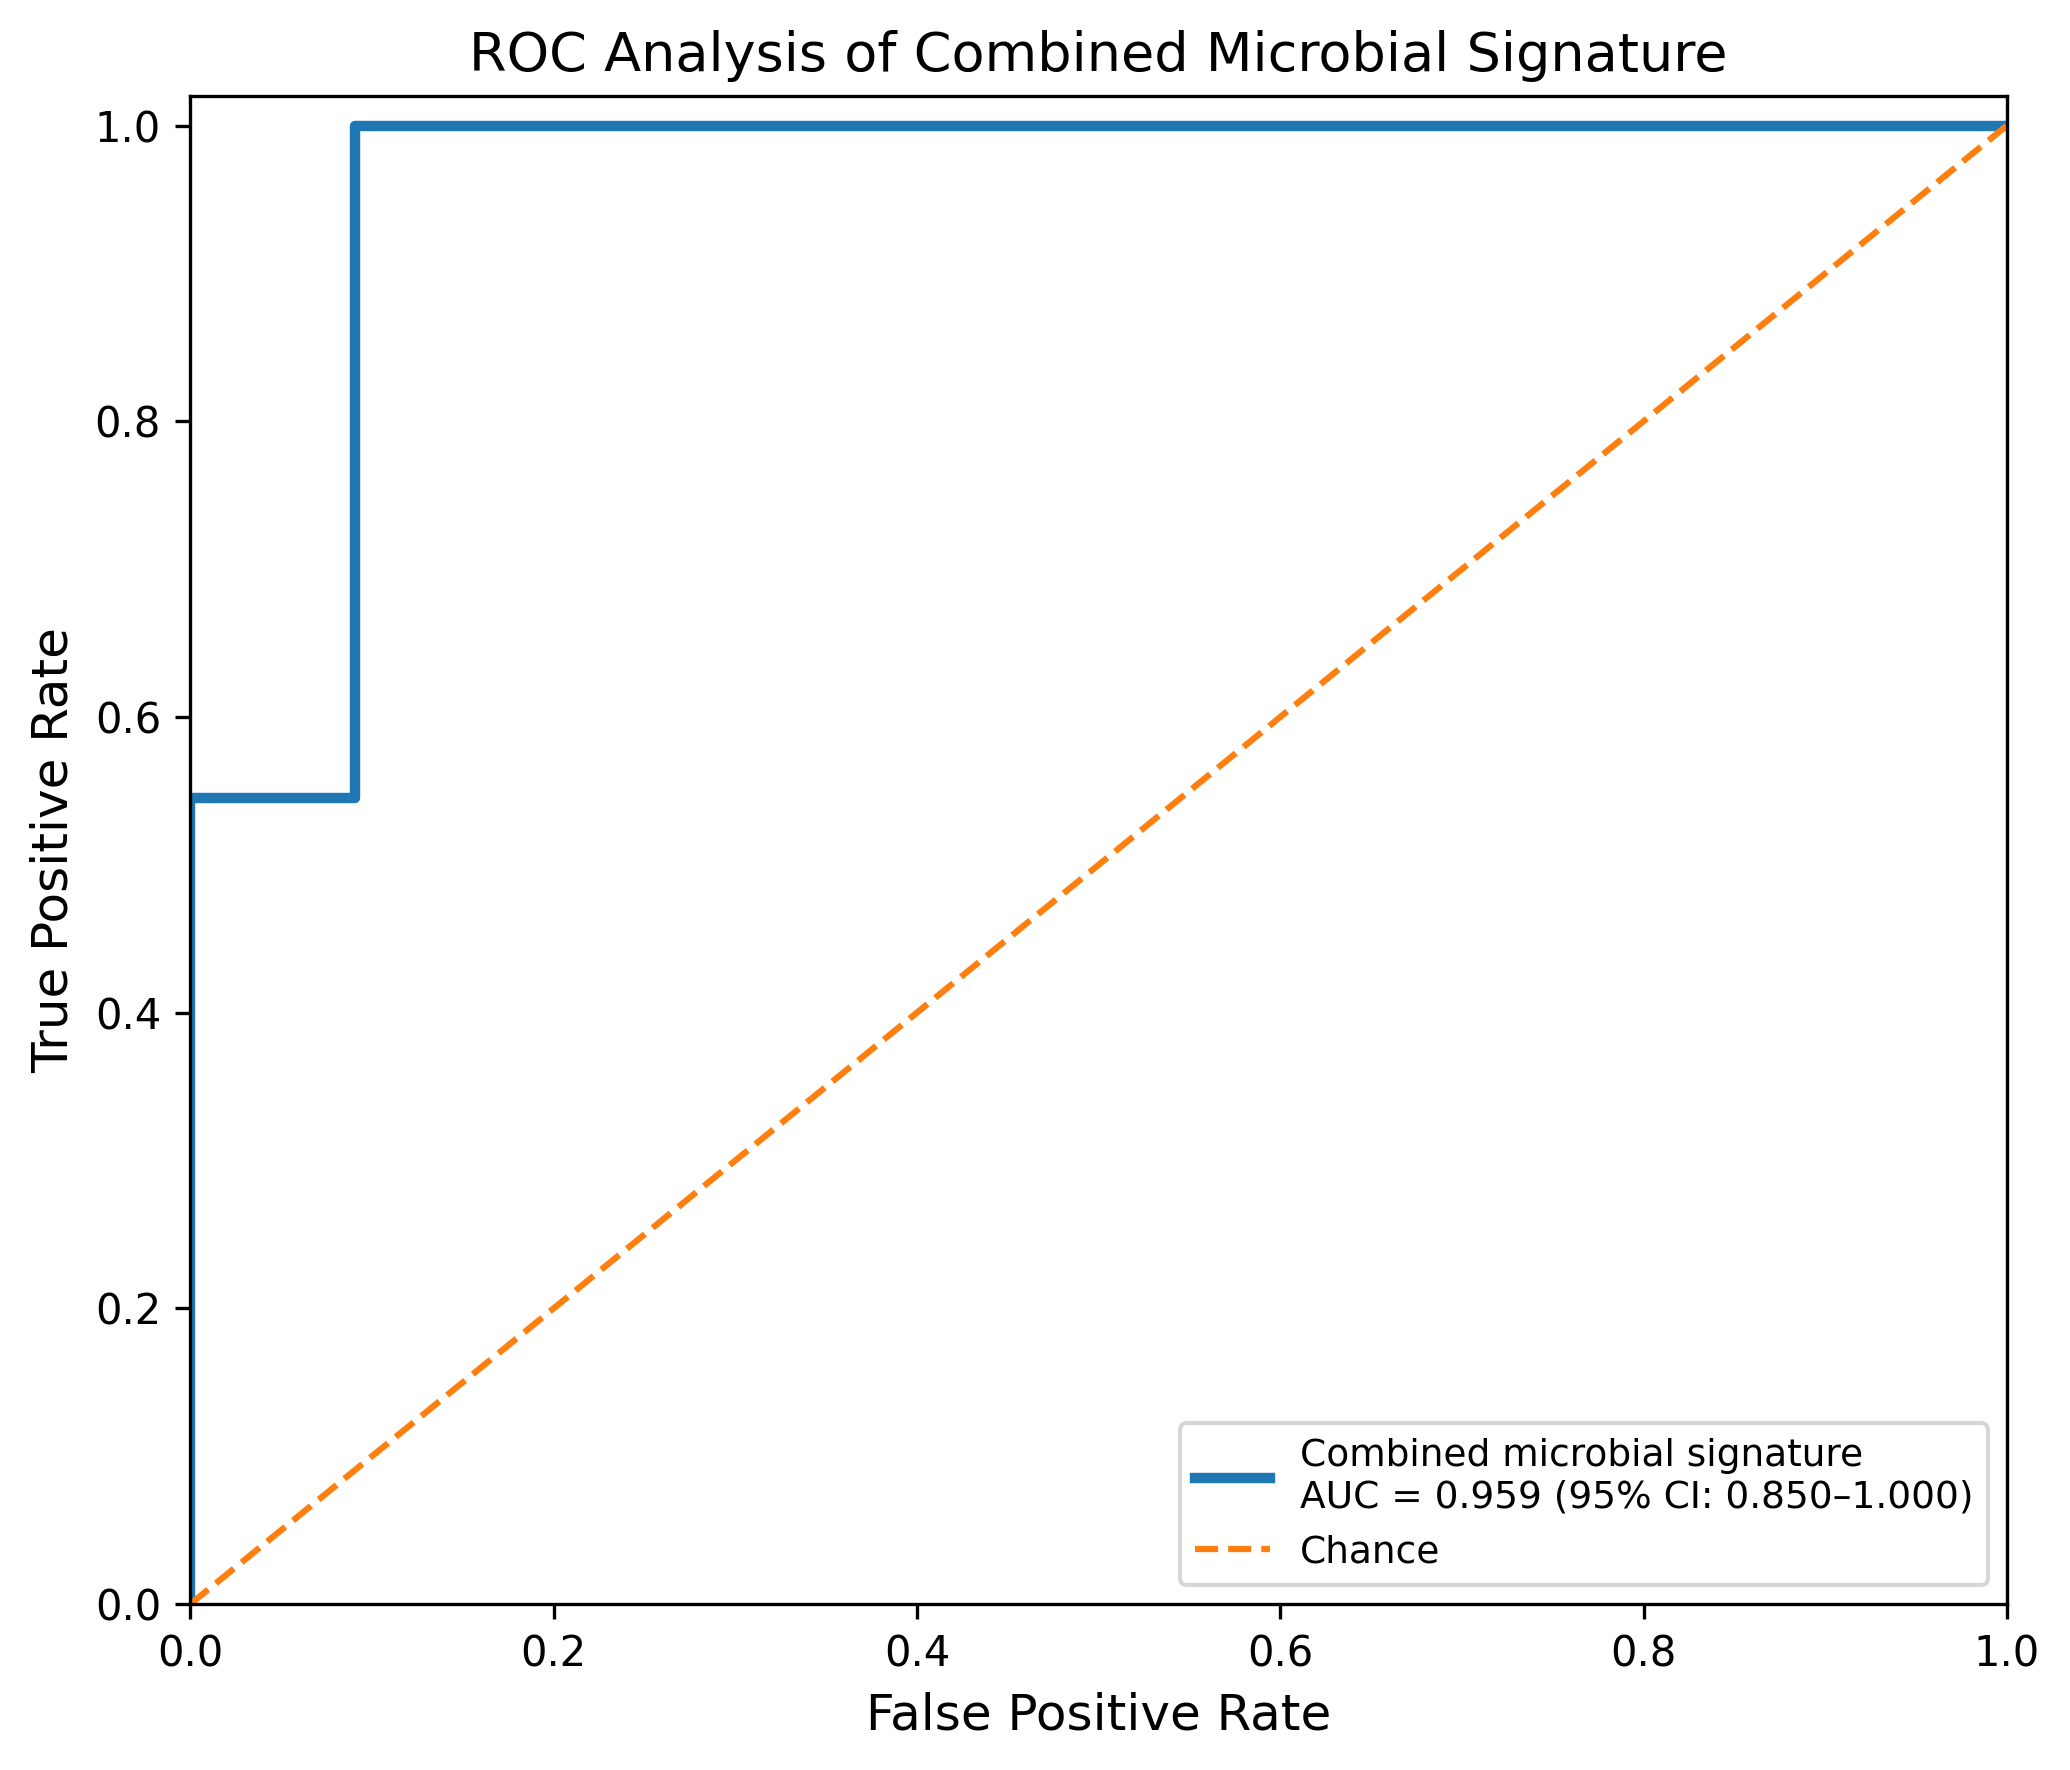


Publication-quality combined ROC figure saved successfully.
Saved at: /content/drive/MyDrive/Step10_Combined_Microbial_Signature_ROC.png


In [ ]:
# ============================================================
# Step 10.7 — Combined Microbial Signature
# Sellimonas + Bifidobacterium + Flavonifractor
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. Define high-priority microbial signature
# ------------------------------------------------------------

signature_taxa = [
    "Sellimonas",
    "Bifidobacterium",
    "Flavonifractor"
]

print("Candidate microbial signature:")
for taxon in signature_taxa:
    print("-", taxon)

# Check that all taxa are present
missing_taxa = [
    taxon for taxon in signature_taxa
    if taxon not in abundance_df.columns
]

if missing_taxa:
    raise ValueError(f"Missing taxa in abundance matrix: {missing_taxa}")

# ------------------------------------------------------------
# 2. Prepare X and y
# ------------------------------------------------------------

X_signature = abundance_df[signature_taxa].copy()

y_signature = abundance_df["Group"].map({
    "Healthy": 0,
    "IBD": 1
}).values

print("\nSignature matrix shape:", X_signature.shape)
print("Class distribution:")
print(pd.Series(y_signature).value_counts().sort_index())

# ------------------------------------------------------------
# 3. Define leakage-aware Logistic Regression pipeline
# ------------------------------------------------------------

signature_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# ------------------------------------------------------------
# 4. Stratified 5-fold cross-validation
# ------------------------------------------------------------

signature_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probabilities
oof_probabilities = cross_val_predict(
    signature_pipeline,
    X_signature,
    y_signature,
    cv=signature_cv,
    method="predict_proba"
)[:, 1]

# Out-of-fold predictions using threshold = 0.50
oof_predictions = (oof_probabilities >= 0.50).astype(int)

# ------------------------------------------------------------
# 5. Calculate performance metrics
# ------------------------------------------------------------

combined_auc = roc_auc_score(
    y_signature,
    oof_probabilities
)

combined_accuracy = accuracy_score(
    y_signature,
    oof_predictions
)

combined_precision = precision_score(
    y_signature,
    oof_predictions,
    zero_division=0
)

combined_recall = recall_score(
    y_signature,
    oof_predictions,
    zero_division=0
)

combined_f1 = f1_score(
    y_signature,
    oof_predictions,
    zero_division=0
)

print("\n================================================")
print("Combined Microbial Signature Performance")
print("================================================")

print(f"ROC-AUC   : {combined_auc:.4f}")
print(f"Accuracy  : {combined_accuracy:.4f}")
print(f"Precision : {combined_precision:.4f}")
print(f"Recall    : {combined_recall:.4f}")
print(f"F1-score  : {combined_f1:.4f}")

# ------------------------------------------------------------
# 6. Calculate ROC curve
# ------------------------------------------------------------

fpr_combined, tpr_combined, thresholds_combined = roc_curve(
    y_signature,
    oof_probabilities
)

# ------------------------------------------------------------
# 7. Sensitivity and specificity at threshold = 0.50
# ------------------------------------------------------------

tn = np.sum((y_signature == 0) & (oof_predictions == 0))
fp = np.sum((y_signature == 0) & (oof_predictions == 1))
fn = np.sum((y_signature == 1) & (oof_predictions == 0))
tp = np.sum((y_signature == 1) & (oof_predictions == 1))

sensitivity_50 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity_50 = tn / (tn + fp) if (tn + fp) > 0 else np.nan

print(f"Sensitivity (threshold 0.50): {sensitivity_50:.4f}")
print(f"Specificity (threshold 0.50): {specificity_50:.4f}")

# ------------------------------------------------------------
# 8. Bootstrap 95% CI for combined OOF ROC-AUC
# ------------------------------------------------------------

def bootstrap_auc_ci(
    y_true,
    predictor,
    n_bootstraps=2000,
    random_state=42
):

    rng = np.random.RandomState(random_state)
    auc_values = []

    for _ in range(n_bootstraps):

        indices = rng.randint(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[indices]
        pred_boot = predictor[indices]

        # Skip samples containing only one class
        if len(np.unique(y_boot)) < 2:
            continue

        auc_values.append(
            roc_auc_score(
                y_boot,
                pred_boot
            )
        )

    lower = np.percentile(
        auc_values,
        2.5
    )

    upper = np.percentile(
        auc_values,
        97.5
    )

    return lower, upper


combined_auc_lower, combined_auc_upper = bootstrap_auc_ci(
    y_signature,
    oof_probabilities,
    n_bootstraps=2000,
    random_state=42
)

print(
    f"ROC-AUC 95% CI: "
    f"{combined_auc_lower:.4f}–{combined_auc_upper:.4f}"
)

# ------------------------------------------------------------
# 9. Create results table
# ------------------------------------------------------------

combined_signature_results = pd.DataFrame({
    "Signature": [
        "Sellimonas + Bifidobacterium + Flavonifractor"
    ],
    "Number_of_Taxa": [len(signature_taxa)],
    "ROC_AUC": [combined_auc],
    "AUC_95CI_Lower": [combined_auc_lower],
    "AUC_95CI_Upper": [combined_auc_upper],
    "Accuracy": [combined_accuracy],
    "Precision": [combined_precision],
    "Sensitivity": [sensitivity_50],
    "Specificity": [specificity_50],
    "F1_Score": [combined_f1],
    "CV_Method": ["Stratified 5-fold OOF"],
    "Classification_Threshold": [0.50]
})

combined_signature_results = combined_signature_results.round({
    "ROC_AUC": 4,
    "AUC_95CI_Lower": 4,
    "AUC_95CI_Upper": 4,
    "Accuracy": 4,
    "Precision": 4,
    "Sensitivity": 4,
    "Specificity": 4,
    "F1_Score": 4
})

display(combined_signature_results)

# ------------------------------------------------------------
# 10. Save combined signature results
# ------------------------------------------------------------

combined_results_path = (
    "/content/drive/MyDrive/"
    "Step10_Combined_Microbial_Signature_Results.csv"
)

combined_signature_results.to_csv(
    combined_results_path,
    index=False
)

print("\nCombined signature results saved successfully.")
print("Saved at:", combined_results_path)

# ------------------------------------------------------------
# 11. Save OOF predictions for reproducibility
# ------------------------------------------------------------

oof_signature_df = abundance_df[
    ["Sample", "Group"]
].copy()

oof_signature_df["Observed_Class"] = y_signature
oof_signature_df["OOF_IBD_Probability"] = oof_probabilities
oof_signature_df["OOF_Predicted_Class"] = oof_predictions

oof_signature_path = (
    "/content/drive/MyDrive/"
    "Step10_Combined_Signature_OOF_Predictions.csv"
)

oof_signature_df.to_csv(
    oof_signature_path,
    index=False
)

print("OOF predictions saved at:", oof_signature_path)

# ------------------------------------------------------------
# 12. Publication-quality ROC curve
# ------------------------------------------------------------

plt.figure(figsize=(7, 6), dpi=300)

plt.plot(
    fpr_combined,
    tpr_combined,
    linewidth=2.5,
    label=(
        "Combined microbial signature\n"
        f"AUC = {combined_auc:.3f} "
        f"(95% CI: {combined_auc_lower:.3f}–"
        f"{combined_auc_upper:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Analysis of Combined Microbial Signature",
    fontsize=13
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()

combined_roc_path = (
    "/content/drive/MyDrive/"
    "Step10_Combined_Microbial_Signature_ROC.png"
)

plt.savefig(
    combined_roc_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nPublication-quality combined ROC figure saved successfully.")
print("Saved at:", combined_roc_path)

In [ ]:
# ============================================================
# STEP 11 — Integrated Candidate Microbial Biomarker Panel
# DESeq2 + ML Feature Importance + ROC-AUC
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load Step 9 integrated candidate table
# ------------------------------------------------------------

step9_path = (
    "/content/drive/MyDrive/"
    "Step9_Integrated_Biomarker_Candidate_Table.csv"
)

step10_path = (
    "/content/drive/MyDrive/"
    "Step10_Individual_ROC_AUC_Results.csv"
)

step9_df = pd.read_csv(step9_path)
step10_df = pd.read_csv(step10_path)

print("Step 9 candidate table shape:", step9_df.shape)
print("Step 10 ROC table shape:", step10_df.shape)

# ------------------------------------------------------------
# 2. Inspect available columns
# ------------------------------------------------------------

print("\nStep 9 columns:")
print(step9_df.columns.tolist())

print("\nStep 10 columns:")
print(step10_df.columns.tolist())

# ------------------------------------------------------------
# 3. Select ROC information
# ------------------------------------------------------------

roc_subset = step10_df[
    [
        "Genus",
        "AUC",
        "AUC_95CI_Lower",
        "AUC_95CI_Upper",
        "Sensitivity",
        "Specificity",
        "Direction"
    ]
].copy()

# ------------------------------------------------------------
# 4. Merge Step 9 evidence with ROC evidence
# ------------------------------------------------------------

integrated_df = step9_df.merge(
    roc_subset,
    on="Genus",
    how="inner"
)

print("\nCandidates with both Step 9 and ROC information:")
print("Shape:", integrated_df.shape)

# ------------------------------------------------------------
# 5. Identify candidates with all three evidence layers
# ------------------------------------------------------------

# DESeq2 significant
integrated_df["DESeq2_Evidence"] = (
    integrated_df["DESeq2_significant"]
    .astype(str)
    .str.lower()
    .isin(["yes", "true", "1"])
)

# ML important
integrated_df["ML_Evidence"] = (
    integrated_df["ML_important"]
    .astype(str)
    .str.lower()
    .isin(["yes", "true", "1"])
)

# ROC available
integrated_df["ROC_Evidence"] = (
    integrated_df["AUC"].notna()
)

# Keep candidates supported by all 3 evidence types
panel_df = integrated_df[
    (integrated_df["DESeq2_Evidence"]) &
    (integrated_df["ML_Evidence"]) &
    (integrated_df["ROC_Evidence"])
].copy()

print("\nCandidates supported by ALL THREE evidence layers:")
print("Number of candidates:", len(panel_df))

print(
    panel_df["Genus"].tolist()
)

# ------------------------------------------------------------
# 6. Rank DESeq2 evidence
# Lower adjusted p-value = stronger evidence
# ------------------------------------------------------------

panel_df["DESeq2_Rank"] = (
    panel_df["padj"]
    .rank(
        method="min",
        ascending=True
    )
)

# ------------------------------------------------------------
# 7. Rank ML feature importance
# Higher importance = stronger evidence
# ------------------------------------------------------------

panel_df["ML_Rank"] = (
    panel_df["Mean_Importance"]
    .rank(
        method="min",
        ascending=False
    )
)

# ------------------------------------------------------------
# 8. Rank ROC-AUC
# Higher AUC = stronger discriminatory performance
# ------------------------------------------------------------

panel_df["ROC_Rank"] = (
    panel_df["AUC"]
    .rank(
        method="min",
        ascending=False
    )
)

# ------------------------------------------------------------
# 9. Calculate integrated rank score
# ------------------------------------------------------------

panel_df["Composite_Rank_Score"] = (
    panel_df["DESeq2_Rank"] +
    panel_df["ML_Rank"] +
    panel_df["ROC_Rank"]
)

# Mean rank across the three evidence layers
panel_df["Mean_Evidence_Rank"] = (
    panel_df["Composite_Rank_Score"] / 3
)

# ------------------------------------------------------------
# 10. Sort by integrated evidence
# ------------------------------------------------------------

# Primary sorting:
# 1. Composite rank score — lower is better
# 2. ML importance — higher is better as tie-breaker

panel_df = panel_df.sort_values(
    by=[
        "Composite_Rank_Score",
        "Mean_Importance"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# 11. Assign final biomarker panel rank
# ------------------------------------------------------------

panel_df.insert(
    0,
    "Biomarker_Rank",
    range(1, len(panel_df) + 1)
)

# ------------------------------------------------------------
# 12. Display final integrated panel
# ------------------------------------------------------------

final_panel_columns = [
    "Biomarker_Rank",
    "Genus",
    "DESeq2_significant",
    "padj",
    "DESeq2_Rank",
    "Mean_Importance",
    "ML_Rank",
    "AUC",
    "AUC_95CI_Lower",
    "AUC_95CI_Upper",
    "ROC_Rank",
    "Composite_Rank_Score",
    "Mean_Evidence_Rank",
    "Sensitivity",
    "Specificity",
    "Direction"
]

final_panel_df = panel_df[
    final_panel_columns
].copy()

# Round numerical values
final_panel_df = final_panel_df.round({
    "padj": 6,
    "Mean_Importance": 6,
    "AUC": 4,
    "AUC_95CI_Lower": 4,
    "AUC_95CI_Upper": 4,
    "Composite_Rank_Score": 2,
    "Mean_Evidence_Rank": 2,
    "Sensitivity": 4,
    "Specificity": 4
})

display(final_panel_df)

# ------------------------------------------------------------
# 13. Save integrated biomarker panel
# ------------------------------------------------------------

panel_output_path = (
    "/content/drive/MyDrive/"
    "Step11_Integrated_Biomarker_Panel.csv"
)

final_panel_df.to_csv(
    panel_output_path,
    index=False
)

print("\n================================================")
print("STEP 11 COMPLETED")
print("================================================")

print(
    "Integrated biomarker panel saved successfully."
)

print(
    "Saved at:",
    panel_output_path
)

Step 9 candidate table shape: (64, 11)
Step 10 ROC table shape: (27, 9)

Step 9 columns:
['Genus', 'DESeq2_significant', 'Rank', 'Mean_Importance', 'ML_important', 'Functional_association', 'log2FoldChange', 'pvalue', 'padj', 'Evidence_score', 'Priority']

Step 10 columns:
['ROC_Rank', 'Genus', 'Direction', 'AUC', 'AUC_95CI_Lower', 'AUC_95CI_Upper', 'Optimal_Threshold', 'Sensitivity', 'Specificity']

Candidates with both Step 9 and ROC information:
Shape: (27, 17)

Candidates supported by ALL THREE evidence layers:
Number of candidates: 5
['Sellimonas', 'Bifidobacterium', 'Flavonifractor', 'Segatella', 'Paludicola']


,Biomarker_Rank,Genus,DESeq2_significant,padj,DESeq2_Rank,Mean_Importance,ML_Rank,AUC,AUC_95CI_Lower,AUC_95CI_Upper,ROC_Rank,Composite_Rank_Score,Mean_Evidence_Rank,Sensitivity,Specificity,Direction
0,1,Segatella,Yes,0.000000,1.0,0.073757,1.0,1.0000,1.0000,1.0,1.0,3.0,1.00,1.0000,1.0000,Higher abundance → IBD
1,2,Sellimonas,Yes,0.000004,2.0,0.068699,2.0,0.9917,0.9500,1.0,2.0,6.0,2.00,0.9091,1.0000,Lower abundance → IBD
2,3,Paludicola,Yes,0.020347,4.0,0.050991,3.0,0.9835,0.9231,1.0,3.0,10.0,3.33,0.9091,1.0000,Lower abundance → IBD
3,4,Bifidobacterium,Yes,0.024117,5.0,0.048550,4.0,0.9669,0.8803,1.0,4.0,13.0,4.33,0.9091,0.9091,Lower abundance → IBD
4,5,Flavonifractor,Yes,0.000282,3.0,0.035823,5.0,0.8926,0.7232,1.0,5.0,13.0,4.33,0.8182,1.0000,Lower abundance → IBD



STEP 11 COMPLETED
Integrated biomarker panel saved successfully.
Saved at: /content/drive/MyDrive/Step11_Integrated_Biomarker_Panel.csv


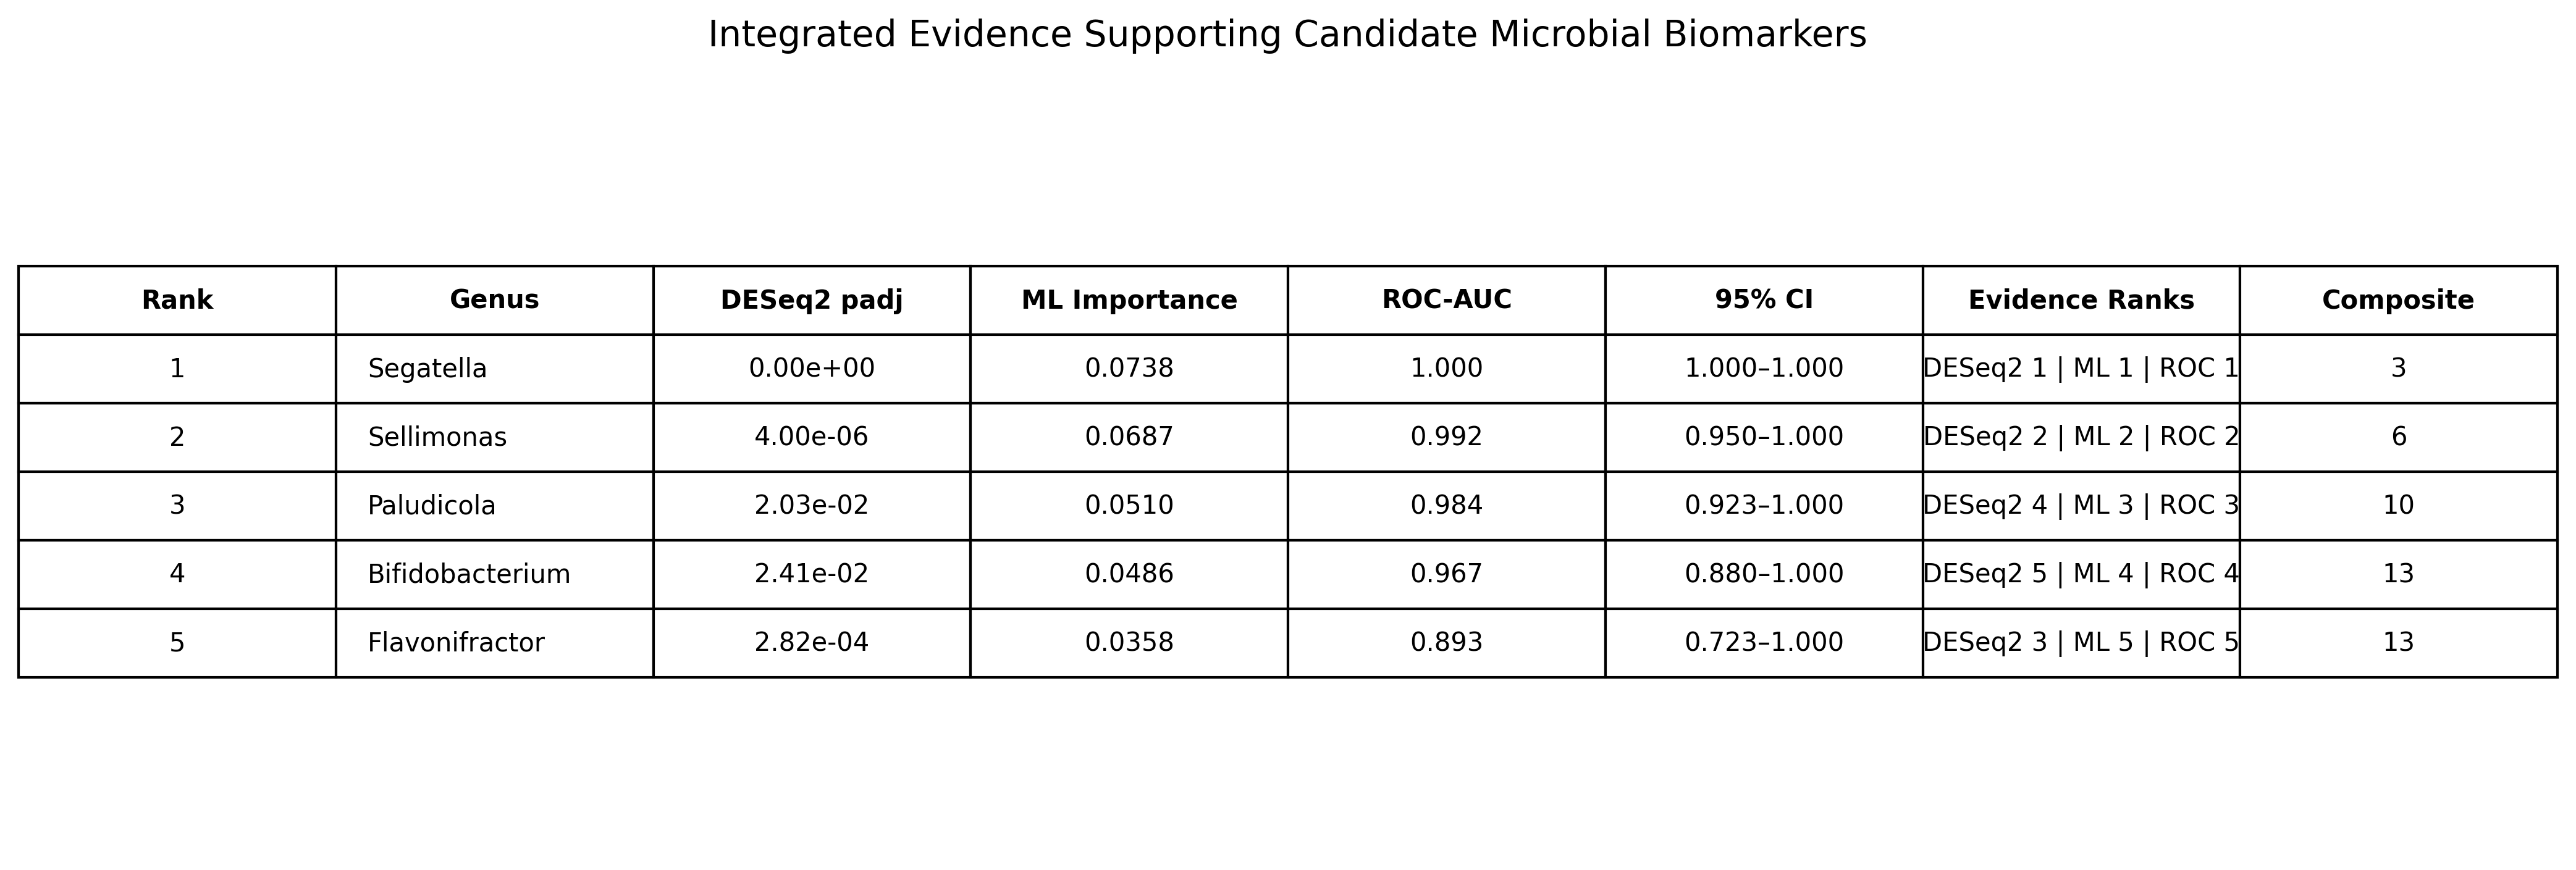

STEP 11.1 COMPLETED
PNG saved at:
/content/drive/MyDrive/Step11_Integrated_Biomarker_Evidence_Figure.png

PDF saved at:
/content/drive/MyDrive/Step11_Integrated_Biomarker_Evidence_Figure.pdf


In [ ]:
# ============================================================
# STEP 11.1 — Publication-Ready Biomarker Evidence Figure
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Use final Step 11 biomarker panel
# ------------------------------------------------------------

figure_df = final_panel_df.copy()

# Keep Top 5 only
figure_df = figure_df.sort_values(
    "Biomarker_Rank"
).head(5)

# ------------------------------------------------------------
# 2. Prepare publication-friendly values
# ------------------------------------------------------------

# Convert adjusted p-value to scientific notation
figure_df["DESeq2_padj"] = figure_df["padj"].apply(
    lambda x: f"{x:.2e}"
)

figure_df["ML_Importance"] = figure_df[
    "Mean_Importance"
].apply(
    lambda x: f"{x:.4f}"
)

figure_df["ROC_AUC"] = figure_df[
    "AUC"
].apply(
    lambda x: f"{x:.3f}"
)

figure_df["AUC_95CI"] = figure_df.apply(
    lambda row:
    f"{row['AUC_95CI_Lower']:.3f}–"
    f"{row['AUC_95CI_Upper']:.3f}",
    axis=1
)

figure_df["Evidence_Ranks"] = figure_df.apply(
    lambda row:
    f"DESeq2 {int(row['DESeq2_Rank'])} | "
    f"ML {int(row['ML_Rank'])} | "
    f"ROC {int(row['ROC_Rank'])}",
    axis=1
)

figure_df["Composite"] = figure_df[
    "Composite_Rank_Score"
].apply(
    lambda x: f"{x:.0f}"
)

# ------------------------------------------------------------
# 3. Create clean table
# ------------------------------------------------------------

table_data = figure_df[
    [
        "Biomarker_Rank",
        "Genus",
        "DESeq2_padj",
        "ML_Importance",
        "ROC_AUC",
        "AUC_95CI",
        "Evidence_Ranks",
        "Composite"
    ]
].values

column_labels = [
    "Rank",
    "Genus",
    "DESeq2 padj",
    "ML Importance",
    "ROC-AUC",
    "95% CI",
    "Evidence Ranks",
    "Composite"
]

# ------------------------------------------------------------
# 4. Generate publication-quality figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 4.8),
    dpi=300
)

ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=column_labels,
    loc="center",
    cellLoc="center"
)

# Font and spacing
table.auto_set_font_size(False)
table.set_fontsize(10)

table.scale(
    1,
    2.0
)

# Make genus names left aligned
for row in range(1, len(table_data) + 1):
    table[(row, 1)].get_text().set_ha("left")

# Bold header
for col in range(len(column_labels)):
    table[(0, col)].get_text().set_weight("bold")

# Figure title
plt.title(
    "Integrated Evidence Supporting Candidate Microbial Biomarkers",
    fontsize=14,
    pad=18
)

plt.tight_layout()

# ------------------------------------------------------------
# 5. Save high-resolution PNG
# ------------------------------------------------------------

figure_png_path = (
    "/content/drive/MyDrive/"
    "Step11_Integrated_Biomarker_Evidence_Figure.png"
)

plt.savefig(
    figure_png_path,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 6. Save vector PDF for manuscript
# ------------------------------------------------------------

figure_pdf_path = (
    "/content/drive/MyDrive/"
    "Step11_Integrated_Biomarker_Evidence_Figure.pdf"
)

plt.savefig(
    figure_pdf_path,
    bbox_inches="tight"
)

plt.show()

print("================================================")
print("STEP 11.1 COMPLETED")
print("================================================")

print("PNG saved at:")
print(figure_png_path)

print("\nPDF saved at:")
print(figure_pdf_path)

In [ ]:
# Identify microbial feature columns
feature_columns = [
    col for col in df.columns
    if col not in ["Sample", "Group"]
]

# Extract microbial abundance features
X = df[feature_columns].copy()

# Apply log1p transformation
X_log = np.log1p(X)

print("Log transformation completed successfully.")
print("Original feature matrix shape:", X.shape)
print("Log-transformed feature matrix shape:", X_log.shape)

X_log.head()

Log transformation completed successfully.
Original feature matrix shape: (22, 68)
Log-transformed feature matrix shape: (22, 68)


,Acidaminococcus,Acutalibacter,Adlercreutzia,Akkermansia,Alistipes,Anaerobutyricum,Anaerocolumna,Anaerostipes,Aristaeella,Aureibaculum,...,Salmonella,Segatella,Sellimonas,Sodalis,Solibaculum,Spirosoma,Streptococcus,Thomasclavelia,Veillonella,Vescimonas
0,0.0,0.0,0.0,0.011553,0.005047,0.011682,0.0,0.005366,0.00059,0.001878,...,0.019557,0.302095,0.0,0.000690,0.022045,0.001719,0.008385,0.0,0.0,0.018576
1,0.0,0.0,0.0,0.000000,0.001379,0.001329,0.0,0.000710,0.00030,0.000680,...,0.000000,0.418579,0.0,0.005147,0.006916,0.002527,0.000000,0.0,0.0,0.006976
2,0.0,0.0,0.0,0.000000,0.001559,0.001119,0.0,0.000980,0.00021,0.000520,...,0.000000,0.416524,0.0,0.004908,0.007700,0.002646,0.000000,0.0,0.0,0.006161
3,0.0,0.0,0.0,0.000000,0.001159,0.001689,0.0,0.003035,0.00033,0.000180,...,0.021615,0.357311,0.0,0.001199,0.002277,0.000870,0.000000,0.0,0.0,0.002936
4,0.0,0.0,0.0,0.000000,0.001559,0.000000,0.0,0.003594,0.00000,0.000220,...,0.000000,0.350368,0.0,0.006707,0.002188,0.002796,0.000000,0.0,0.0,0.002876


### 5.2 Feature Scaling Strategy

Feature scaling will be performed within the machine-learning cross-validation
pipeline rather than being fitted on the complete dataset.

This approach ensures that scaling parameters are learned only from the
training data in each cross-validation fold, thereby reducing the risk of
data leakage into the validation data.

`StandardScaler` will be incorporated into the model pipeline during
cross-validation.

In [ ]:
print(panel_df.columns.tolist())

['Biomarker_Rank', 'Genus', 'DESeq2_significant', 'padj', 'DESeq2_Rank', 'Mean_Importance', 'ML_Rank', 'AUC', 'AUC_95CI_Lower', 'AUC_95CI_Upper', 'ROC_Rank', 'Composite_Rank_Score', 'Mean_Evidence_Rank', 'Sensitivity', 'Specificity', 'Direction']


In [ ]:
# ============================================================
# STEP 12.1 — Biomarker–Pathway Integration
# Top Biomarkers + PICRUSt2 Functional Associations
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load Step 11 biomarker panel
# ------------------------------------------------------------

panel_path = "/content/drive/MyDrive/Step11_Integrated_Biomarker_Panel.csv"

panel_df = pd.read_csv(panel_path)

# ------------------------------------------------------------
# 2. Load significant microbe–pathway correlations
# ------------------------------------------------------------

correlation_path = "/content/drive/MyDrive/Supplementary_Table_S12_Significant_Correlations_FDR.csv"

correlation_df = pd.read_csv(correlation_path)

# ------------------------------------------------------------
# 3. Select Top 5 biomarkers from Step 11
# ------------------------------------------------------------

top5_biomarkers = panel_df["Genus"].head(5).tolist()

print("Top 5 biomarkers:")
print(top5_biomarkers)

# ------------------------------------------------------------
# 4. Extract pathway associations for Top 5 biomarkers
# ------------------------------------------------------------

top5_correlations = correlation_df[
    correlation_df["Genus"].isin(top5_biomarkers)
].copy()

# ------------------------------------------------------------
# 5. Get IBD direction from Step 11
# ------------------------------------------------------------

direction_df = panel_df[
    ["Genus", "Direction"]
].copy()

direction_df = direction_df[
    direction_df["Genus"].isin(top5_biomarkers)
]

direction_df = direction_df.rename(
    columns={"Direction": "Direction_in_IBD"}
)

# ------------------------------------------------------------
# 6. Merge biomarker direction + pathway associations
# ------------------------------------------------------------

integrated_pathway_df = top5_correlations.merge(
    direction_df,
    on="Genus",
    how="left"
)

# ------------------------------------------------------------
# 7. Rename columns for publication-ready table
# ------------------------------------------------------------

integrated_pathway_df = integrated_pathway_df.rename(columns={
    "Pathway": "Predicted_Pathway",
    "Rho": "Spearman_Rho",
    "Pvalue": "Correlation_Pvalue",
    "FDR": "Correlation_FDR"
})

# Keep only required columns
integrated_pathway_df = integrated_pathway_df[
    [
        "Genus",
        "Direction_in_IBD",
        "Predicted_Pathway",
        "Spearman_Rho",
        "Correlation_Pvalue",
        "Correlation_FDR"
    ]
].copy()

# ------------------------------------------------------------
# 8. Add biomarkers with NO significant pathway association
# ------------------------------------------------------------

associated_taxa = set(integrated_pathway_df["Genus"])

missing_taxa = [
    taxon for taxon in top5_biomarkers
    if taxon not in associated_taxa
]

if missing_taxa:

    missing_rows = direction_df[
        direction_df["Genus"].isin(missing_taxa)
    ].copy()

    missing_rows["Predicted_Pathway"] = (
        "No significant association identified"
    )

    missing_rows["Spearman_Rho"] = np.nan
    missing_rows["Correlation_Pvalue"] = np.nan
    missing_rows["Correlation_FDR"] = np.nan

    missing_rows = missing_rows[
        [
            "Genus",
            "Direction_in_IBD",
            "Predicted_Pathway",
            "Spearman_Rho",
            "Correlation_Pvalue",
            "Correlation_FDR"
        ]
    ]

    integrated_pathway_df = pd.concat(
        [integrated_pathway_df, missing_rows],
        ignore_index=True
    )

# ------------------------------------------------------------
# 9. Add biomarker rank
# ------------------------------------------------------------

rank_order = {
    taxon: rank
    for rank, taxon in enumerate(top5_biomarkers, start=1)
}

integrated_pathway_df["Biomarker_Rank"] = (
    integrated_pathway_df["Genus"].map(rank_order)
)

# ------------------------------------------------------------
# 10. Sort in Top-5 biomarker order
# ------------------------------------------------------------

integrated_pathway_df = integrated_pathway_df.sort_values(
    by=["Biomarker_Rank", "Correlation_FDR"],
    na_position="last"
).reset_index(drop=True)

# ------------------------------------------------------------
# 11. Final column order
# ------------------------------------------------------------

integrated_pathway_df = integrated_pathway_df[
    [
        "Biomarker_Rank",
        "Genus",
        "Direction_in_IBD",
        "Predicted_Pathway",
        "Spearman_Rho",
        "Correlation_Pvalue",
        "Correlation_FDR"
    ]
]

# ------------------------------------------------------------
# 12. Round numerical values
# ------------------------------------------------------------

integrated_pathway_df = integrated_pathway_df.round({
    "Spearman_Rho": 4,
    "Correlation_Pvalue": 8,
    "Correlation_FDR": 8
})

# ------------------------------------------------------------
# 13. Display final table
# ------------------------------------------------------------

display(integrated_pathway_df)

# ------------------------------------------------------------
# 14. Save Step 12 output
# ------------------------------------------------------------

step12_output_path = (
    "/content/drive/MyDrive/"
    "Step12_Biomarker_Pathway_Integration.csv"
)

integrated_pathway_df.to_csv(
    step12_output_path,
    index=False
)

print("\nStep 12 table saved successfully.")
print("Saved at:", step12_output_path)
print("Shape:", integrated_pathway_df.shape)

Top 5 biomarkers:
['Segatella', 'Sellimonas', 'Paludicola', 'Bifidobacterium', 'Flavonifractor']


,Biomarker_Rank,Genus,Direction_in_IBD,Predicted_Pathway,Spearman_Rho,Correlation_Pvalue,Correlation_FDR
0,1,Segatella,Higher abundance → IBD,No significant association identified,NaN,NaN,NaN
1,2,Sellimonas,Lower abundance → IBD,PEPTIDOGLYCANSYN-PWY,0.7539,5.080000e-05,3.535800e-04
2,2,Sellimonas,Lower abundance → IBD,LPSSYN-PWY,0.6473,1.128810e-03,5.813380e-03
3,3,Paludicola,Lower abundance → IBD,No significant association identified,NaN,NaN,NaN
4,4,Bifidobacterium,Lower abundance → IBD,LPSSYN-PWY,0.8806,6.000000e-08,2.200000e-06
5,4,Bifidobacterium,Lower abundance → IBD,PEPTIDOGLYCANSYN-PWY,0.8692,1.500000e-07,4.500000e-06
6,5,Flavonifractor,Lower abundance → IBD,PEPTIDOGLYCANSYN-PWY,0.9089,0.000000e+00,4.000000e-07
7,5,Flavonifractor,Lower abundance → IBD,LPSSYN-PWY,0.7955,9.640000e-06,9.030000e-05



Step 12 table saved successfully.
Saved at: /content/drive/MyDrive/Step12_Biomarker_Pathway_Integration.csv
Shape: (8, 7)


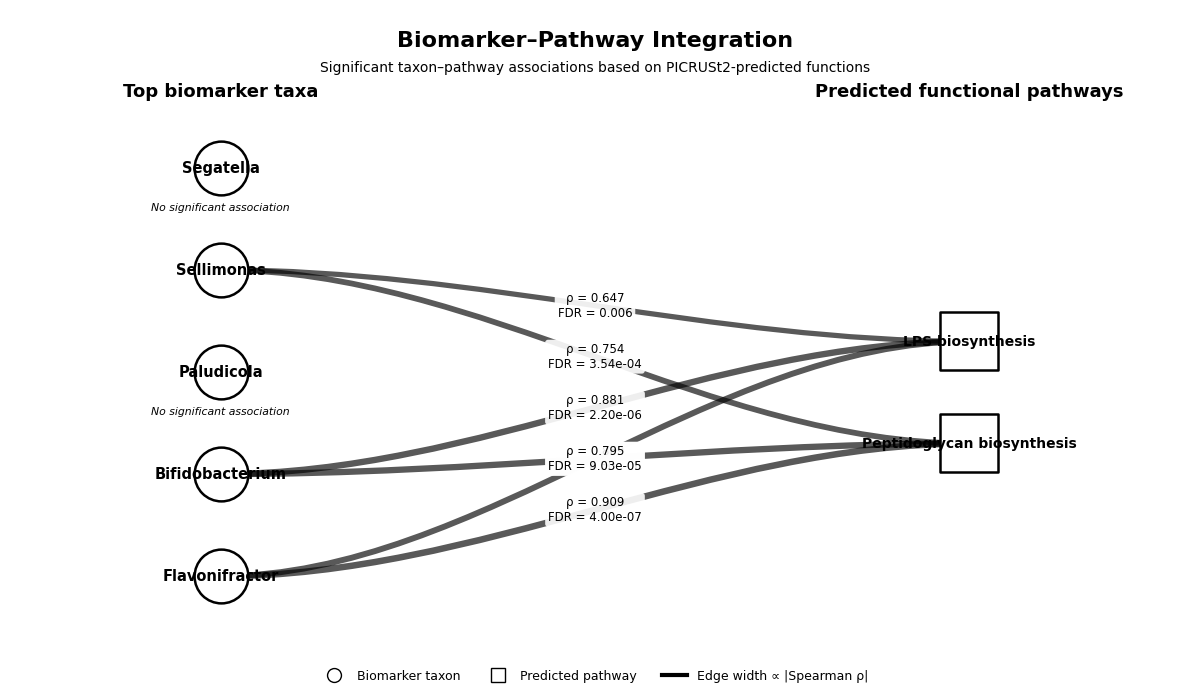

STEP 12.2 COMPLETED SUCCESSFULLY
PNG saved: /content/drive/MyDrive/Step12_Biomarker_Pathway_Network.png
PDF saved: /content/drive/MyDrive/Step12_Biomarker_Pathway_Network.pdf


In [ ]:
# ============================================================
# STEP 12.2 — Publication-Quality Biomarker–Pathway Network
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Load Step 12 results
# ------------------------------------------------------------

input_path = "/content/drive/MyDrive/Step12_Biomarker_Pathway_Integration.csv"

df = pd.read_csv(input_path)

# ------------------------------------------------------------
# 2. Separate significant pathway associations
# ------------------------------------------------------------

edges = df[
    df["Predicted_Pathway"] !=
    "No significant association identified"
].copy()

# ------------------------------------------------------------
# 3. Friendly pathway names
# ------------------------------------------------------------

pathway_labels = {
    "LPSSYN-PWY": "LPS biosynthesis",
    "PEPTIDOGLYCANSYN-PWY": "Peptidoglycan biosynthesis"
}

edges["Pathway_Label"] = edges["Predicted_Pathway"].map(
    lambda x: pathway_labels.get(x, x)
)

# ------------------------------------------------------------
# 4. Define biomarker order
# ------------------------------------------------------------

biomarkers = [
    "Segatella",
    "Sellimonas",
    "Paludicola",
    "Bifidobacterium",
    "Flavonifractor"
]

pathways = [
    "LPS biosynthesis",
    "Peptidoglycan biosynthesis"
]

# ------------------------------------------------------------
# 5. Node positions
# ------------------------------------------------------------

bio_y = {
    "Segatella": 4.5,
    "Sellimonas": 3.5,
    "Paludicola": 2.5,
    "Bifidobacterium": 1.5,
    "Flavonifractor": 0.5
}

path_y = {
    "LPS biosynthesis": 2.8,
    "Peptidoglycan biosynthesis": 1.8
}

# ------------------------------------------------------------
# 6. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

# ------------------------------------------------------------
# 7. Draw biomarker → pathway associations
# ------------------------------------------------------------

for _, row in edges.iterrows():

    genus = row["Genus"]
    pathway = row["Pathway_Label"]

    x1, y1 = 0.18, bio_y[genus]
    x2, y2 = 0.82, path_y[pathway]

    rho = float(row["Spearman_Rho"])
    fdr = float(row["Correlation_FDR"])

    # Edge width reflects correlation strength
    linewidth = 1.5 + 3.5 * abs(rho)

    # Curved connection
    vertices = [
        (x1, y1),
        (0.40, y1),
        (0.60, y2),
        (x2, y2)
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    curve = PathPatch(
        Path(vertices, codes),
        fill=False,
        linewidth=linewidth,
        alpha=0.65
    )

    ax.add_patch(curve)

    # FDR formatting
    if fdr < 0.001:
        fdr_text = f"{fdr:.2e}"
    else:
        fdr_text = f"{fdr:.3f}"

    # Edge annotation
    label_y = (y1 + y2) / 2

    ax.text(
        0.50,
        label_y,
        f"ρ = {rho:.3f}\nFDR = {fdr_text}",
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        )
    )

# ------------------------------------------------------------
# 8. Biomarker nodes
# ------------------------------------------------------------

associated_taxa = set(edges["Genus"])

for genus, y in bio_y.items():

    has_association = genus in associated_taxa

    ax.scatter(
        0.18,
        y,
        s=1500,
        marker="o",
        facecolors="white",
        edgecolors="black",
        linewidths=1.8,
        zorder=5
    )

    ax.text(
        0.18,
        y,
        genus,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        zorder=6
    )

    # Mark taxa without significant pathway association
    if not has_association:

        ax.text(
            0.18,
            y - 0.34,
            "No significant association",
            ha="center",
            va="top",
            fontsize=7.8,
            style="italic"
        )

# ------------------------------------------------------------
# 9. Pathway nodes
# ------------------------------------------------------------

for pathway, y in path_y.items():

    ax.scatter(
        0.82,
        y,
        s=1800,
        marker="s",
        facecolors="white",
        edgecolors="black",
        linewidths=1.8,
        zorder=5
    )

    ax.text(
        0.82,
        y,
        pathway,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=6
    )

# ------------------------------------------------------------
# 10. Section labels
# ------------------------------------------------------------

ax.text(
    0.18,
    5.25,
    "Top biomarker taxa",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    0.82,
    5.25,
    "Predicted functional pathways",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# ------------------------------------------------------------
# 11. Figure title
# ------------------------------------------------------------

ax.text(
    0.50,
    5.75,
    "Biomarker–Pathway Integration",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.50,
    5.48,
    "Significant taxon–pathway associations based on PICRUSt2-predicted functions",
    ha="center",
    va="center",
    fontsize=10
)

# ------------------------------------------------------------
# 12. Legend
# ------------------------------------------------------------

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=10,
        label="Biomarker taxon"
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=10,
        label="Predicted pathway"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=3,
        label="Edge width ∝ |Spearman ρ|"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.50, -0.08),
    ncol=3,
    frameon=False,
    fontsize=9
)

# ------------------------------------------------------------
# 13. Formatting
# ------------------------------------------------------------

ax.set_xlim(0, 1)
ax.set_ylim(-0.15, 6.05)

ax.axis("off")

plt.tight_layout()

# ------------------------------------------------------------
# 14. Save high-resolution PNG + PDF
# ------------------------------------------------------------

png_path = (
    "/content/drive/MyDrive/"
    "Step12_Biomarker_Pathway_Network.png"
)

pdf_path = (
    "/content/drive/MyDrive/"
    "Step12_Biomarker_Pathway_Network.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("==============================================")
print("STEP 12.2 COMPLETED SUCCESSFULLY")
print("==============================================")
print("PNG saved:", png_path)
print("PDF saved:", pdf_path)

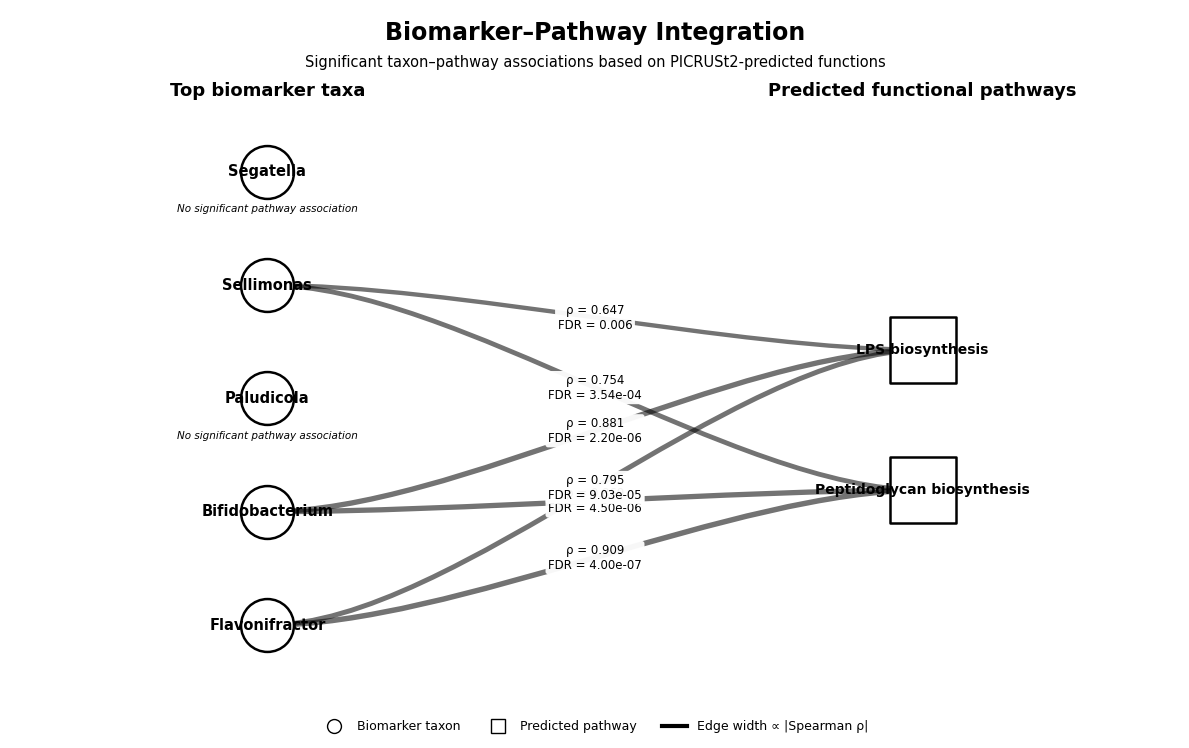

STEP 12.2 FINAL COMPLETED
PNG: /content/drive/MyDrive/Step12_Biomarker_Pathway_Network_Final.png
PDF: /content/drive/MyDrive/Step12_Biomarker_Pathway_Network_Final.pdf


In [ ]:
# ============================================================
# STEP 12.2 FINAL — Clean Biomarker–Pathway Network
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Load Step 12 table
# ------------------------------------------------------------

input_path = "/content/drive/MyDrive/Step12_Biomarker_Pathway_Integration.csv"

df = pd.read_csv(input_path)

# ------------------------------------------------------------
# Significant associations only
# ------------------------------------------------------------

edges = df[
    df["Predicted_Pathway"] !=
    "No significant association identified"
].copy()

# Friendly pathway names
pathway_names = {
    "LPSSYN-PWY": "LPS biosynthesis",
    "PEPTIDOGLYCANSYN-PWY": "Peptidoglycan biosynthesis"
}

edges["Pathway_Label"] = edges["Predicted_Pathway"].map(
    lambda x: pathway_names.get(x, x)
)

# ------------------------------------------------------------
# Biomarker order
# ------------------------------------------------------------

biomarkers = [
    "Segatella",
    "Sellimonas",
    "Paludicola",
    "Bifidobacterium",
    "Flavonifractor"
]

# ------------------------------------------------------------
# Positions
# ------------------------------------------------------------

bio_y = {
    "Segatella": 4.5,
    "Sellimonas": 3.45,
    "Paludicola": 2.4,
    "Bifidobacterium": 1.35,
    "Flavonifractor": 0.30
}

path_y = {
    "LPS biosynthesis": 2.85,
    "Peptidoglycan biosynthesis": 1.55
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7.5))

# ------------------------------------------------------------
# Draw edges
# ------------------------------------------------------------

for _, row in edges.iterrows():

    genus = row["Genus"]
    pathway = row["Pathway_Label"]

    x1, y1 = 0.22, bio_y[genus]
    x2, y2 = 0.78, path_y[pathway]

    rho = float(row["Spearman_Rho"])
    fdr = float(row["Correlation_FDR"])

    # Stronger correlation = thicker edge
    linewidth = 1.2 + 3.0 * abs(rho)

    vertices = [
        (x1, y1),
        (0.38, y1),
        (0.62, y2),
        (x2, y2)
    ]

    curve = PathPatch(
        Path(
            vertices,
            [
                Path.MOVETO,
                Path.CURVE4,
                Path.CURVE4,
                Path.CURVE4
            ]
        ),
        fill=False,
        linewidth=linewidth,
        alpha=0.55,
        zorder=1
    )

    ax.add_patch(curve)

    # FDR formatting
    fdr_text = f"{fdr:.2e}" if fdr < 0.001 else f"{fdr:.3f}"

    # Place label centrally
    label_y = (y1 + y2) / 2

    ax.text(
        0.50,
        label_y,
        f"ρ = {rho:.3f}\nFDR = {fdr_text}",
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="none",
            alpha=0.95
        ),
        zorder=3
    )

# ------------------------------------------------------------
# Biomarker nodes
# ------------------------------------------------------------

associated_taxa = set(edges["Genus"])

for genus in biomarkers:

    y = bio_y[genus]

    ax.scatter(
        0.22,
        y,
        s=1450,
        marker="o",
        facecolors="white",
        edgecolors="black",
        linewidths=1.8,
        zorder=5
    )

    ax.text(
        0.22,
        y,
        genus,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        zorder=6
    )

    # No significant association
    if genus not in associated_taxa:

        ax.text(
            0.22,
            y - 0.30,
            "No significant pathway association",
            ha="center",
            va="top",
            fontsize=7.5,
            style="italic"
        )

# ------------------------------------------------------------
# Pathway nodes
# ------------------------------------------------------------

for pathway, y in path_y.items():

    ax.scatter(
        0.78,
        y,
        s=2200,
        marker="s",
        facecolors="white",
        edgecolors="black",
        linewidths=1.8,
        zorder=5
    )

    ax.text(
        0.78,
        y,
        pathway,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=6
    )

# ------------------------------------------------------------
# Headers
# ------------------------------------------------------------

ax.text(
    0.22,
    5.20,
    "Top biomarker taxa",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    0.78,
    5.20,
    "Predicted functional pathways",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0.50,
    5.72,
    "Biomarker–Pathway Integration",
    ha="center",
    fontsize=17,
    fontweight="bold"
)

ax.text(
    0.50,
    5.47,
    "Significant taxon–pathway associations based on PICRUSt2-predicted functions",
    ha="center",
    fontsize=10.5
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=10,
        label="Biomarker taxon"
    ),

    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=10,
        label="Predicted pathway"
    ),

    Line2D(
        [0], [0],
        color="black",
        linewidth=3,
        label="Edge width ∝ |Spearman ρ|"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.50, -0.08),
    ncol=3,
    frameon=False,
    fontsize=9
)

# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------

ax.set_xlim(0, 1)
ax.set_ylim(-0.30, 6.0)
ax.axis("off")

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

png_path = (
    "/content/drive/MyDrive/"
    "Step12_Biomarker_Pathway_Network_Final.png"
)

pdf_path = (
    "/content/drive/MyDrive/"
    "Step12_Biomarker_Pathway_Network_Final.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("==============================================")
print("STEP 12.2 FINAL COMPLETED")
print("==============================================")
print("PNG:", png_path)
print("PDF:", pdf_path)

In [ ]:
import pandas as pd

network = pd.read_csv("/content/drive/MyDrive/Microbe_Pathway_Network.csv")
biomarkers = pd.read_csv("/content/drive/MyDrive/Step11_Integrated_Biomarker_Panel.csv")
rf = pd.read_csv("/content/drive/MyDrive/RF_feature_importance.csv")

print("Network shape:", network.shape)
print("Biomarker panel shape:", biomarkers.shape)
print("RF importance shape:", rf.shape)

print("\nNetwork columns:")
print(network.columns.tolist())

print("\nTop 5 biomarkers:")
print(biomarkers.head(5)[["Biomarker_Rank", "Genus"]])

print("\nTop RF features:")
print(rf.head(10))

Network shape: (72, 5)
Biomarker panel shape: (5, 16)
RF importance shape: (68, 3)

Network columns:
['Genus', 'Pathway', 'Rho', 'Pvalue', 'FDR']

Top 5 biomarkers:
   Biomarker_Rank            Genus
0               1        Segatella
1               2       Sellimonas
2               3       Paludicola
3               4  Bifidobacterium
4               5   Flavonifractor

Top RF features:
   Rank               Genus  Mean_Importance
0     1             Sodalis         0.095612
1     2        Enterococcus         0.087943
2     3           Segatella         0.073757
3     4          Sellimonas         0.068699
4     5       Adlercreutzia         0.053133
5     6          Paludicola         0.050991
6     7     Bifidobacterium         0.048550
7     8       Anaerocolumna         0.044398
8     9      Flavonifractor         0.035823
9    10  Mediterraneibacter         0.031800


In [ ]:
import pandas as pd
import numpy as np

# ==============================
# STEP 13 — LOAD FILES
# ==============================

network = pd.read_csv(
    "/content/drive/MyDrive/Microbe_Pathway_Network.csv"
)

biomarkers = pd.read_csv(
    "/content/drive/MyDrive/Step11_Integrated_Biomarker_Panel.csv"
)

rf = pd.read_csv(
    "/content/drive/MyDrive/RF_feature_importance.csv"
)

print("Network:", network.shape)
print("Biomarkers:", biomarkers.shape)
print("RF:", rf.shape)


# ==============================
# TOP 5 BIOMARKERS
# ==============================

top5_biomarkers = biomarkers.head(5)["Genus"].tolist()

print("\nTop 5 Candidate Biomarkers:")
print(top5_biomarkers)


# ==============================
# PATHWAY NAME MAPPING
# ==============================

pathway_names = {
    "LPSSYN-PWY": "LPS biosynthesis",
    "PEPTIDOGLYCANSYN-PWY": "Peptidoglycan biosynthesis"
}


# ==============================
# CREATE EDGE TABLE
# ==============================

edges = network.copy()

edges["Source"] = edges["Genus"]
edges["Target"] = edges["Pathway"].map(pathway_names)

# Keep original pathway ID as well
edges["Pathway_ID"] = edges["Pathway"]

edges["Interaction"] = "Significant correlation"

# Edge weight based on absolute Spearman correlation
edges["Weight"] = edges["Rho"].abs()

edge_table = edges[
    [
        "Source",
        "Target",
        "Interaction",
        "Rho",
        "Pvalue",
        "FDR",
        "Weight",
        "Pathway_ID"
    ]
].copy()

edge_path = "/content/drive/MyDrive/Step13_Biomarker_Focused_Edge_Table.csv"

edge_table.to_csv(edge_path, index=False)


# ==============================
# CREATE NODE TABLE
# ==============================

# RF importance dictionary
rf_importance = dict(
    zip(rf["Genus"], rf["Mean_Importance"])
)

# Degree of each microbe
microbe_degree = network["Genus"].value_counts().to_dict()

# Degree of pathways
pathway_degree = network["Pathway"].value_counts().to_dict()

# Direction from Step 11
direction_dict = dict(
    zip(biomarkers["Genus"], biomarkers["Direction"])
)

nodes = []

# ---- Microbial nodes ----
for genus in network["Genus"].unique():

    if genus in top5_biomarkers:
        category = "Candidate biomarker"
    else:
        category = "Microbe"

    degree = microbe_degree.get(genus, 0)
    importance = rf_importance.get(genus, np.nan)

    # Candidate biomarkers use ML importance
    if category == "Candidate biomarker":
        size_metric = importance
    else:
        size_metric = degree

    nodes.append({
        "Node": genus,
        "Category": category,
        "ML_Importance": importance,
        "Network_Degree": degree,
        "Node_Size_Metric": size_metric,
        "Direction_in_IBD": direction_dict.get(genus, "")
    })


# ---- Add biomarkers with zero network degree ----
# This keeps Segatella and Paludicola visible
# even though they have no significant edge in the 72-edge network.

for genus in top5_biomarkers:

    if genus not in network["Genus"].unique():

        importance = rf_importance.get(genus, np.nan)

        nodes.append({
            "Node": genus,
            "Category": "Candidate biomarker",
            "ML_Importance": importance,
            "Network_Degree": 0,
            "Node_Size_Metric": importance,
            "Direction_in_IBD": direction_dict.get(genus, "")
        })


# ---- Pathway nodes ----
for pathway_id in network["Pathway"].unique():

    pathway_name = pathway_names.get(pathway_id, pathway_id)
    degree = pathway_degree.get(pathway_id, 0)

    nodes.append({
        "Node": pathway_name,
        "Category": "Pathway",
        "ML_Importance": np.nan,
        "Network_Degree": degree,
        "Node_Size_Metric": degree,
        "Direction_in_IBD": ""
    })


node_table = pd.DataFrame(nodes)

node_path = "/content/drive/MyDrive/Step13_Biomarker_Focused_Node_Table.csv"

node_table.to_csv(node_path, index=False)


# ==============================
# CHECK RESULTS
# ==============================

print("\n===================================")
print("STEP 13 FILES SAVED SUCCESSFULLY")
print("===================================")

print("\nNode table:")
print(node_table.shape)

print("\nEdge table:")
print(edge_table.shape)

print("\nNode categories:")
print(node_table["Category"].value_counts())

print("\nPathway interactions:")
print(network["Pathway"].value_counts())

print("\nFiles saved to Google Drive:")
print(node_path)
print(edge_path)

Network: (72, 5)
Biomarkers: (5, 16)
RF: (68, 3)

Top 5 Candidate Biomarkers:
['Segatella', 'Sellimonas', 'Paludicola', 'Bifidobacterium', 'Flavonifractor']

STEP 13 FILES SAVED SUCCESSFULLY

Node table:
(44, 6)

Edge table:
(72, 8)

Node categories:
Category
Microbe                37
Candidate biomarker     5
Pathway                 2
Name: count, dtype: int64

Pathway interactions:
Pathway
LPSSYN-PWY              37
PEPTIDOGLYCANSYN-PWY    35
Name: count, dtype: int64

Files saved to Google Drive:
/content/drive/MyDrive/Step13_Biomarker_Focused_Node_Table.csv
/content/drive/MyDrive/Step13_Biomarker_Focused_Edge_Table.csv


In [ ]:
# Confirm the log-transformed feature matrix
print("Final log-transformed feature matrix:")
print("Samples:", X_log.shape[0])
print("Microbial features:", X_log.shape[1])
print("Missing values:", X_log.isnull().sum().sum())

Final log-transformed feature matrix:
Samples: 22
Microbial features: 68
Missing values: 0


## 6. Define the Prediction Problem

The machine-learning task is formulated as a binary classification problem.

Healthy-control samples are assigned a class label of 0, whereas IBD samples
are assigned a class label of 1.

The microbial genus abundances are used as predictor variables (X), and disease
status is used as the target variable (y).

In [ ]:
# Define predictor variables (X)
# Only microbial genus features are included as predictors.

X = X_log.copy()

# Convert disease status into binary labels
# Healthy = 0
# IBD = 1

y = df["Group"].map({
    "Healthy": 0,
    "IBD": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts().sort_index())

print("\nUnique target labels:")
print(y.unique())

X shape: (22, 68)
y shape: (22,)

Class distribution:
Group
0    11
1    11
Name: count, dtype: int64

Unique target labels:
[1 0]


## 7. Stratified 5-Fold Cross-Validation

Because the dataset contains only 22 samples, a conventional 80:20 train-test
split is not used as the primary validation strategy.

Instead, stratified 5-fold cross-validation is used to maximize the use of the
available samples while maintaining the distribution of IBD and healthy-control
samples across the folds.

A fixed random state is used to ensure reproducibility.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Define stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Stratified 5-fold cross-validation initialized.")
print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Stratified 5-fold cross-validation initialized.
Number of folds: 5
Shuffle: True
Random state: 42


In [ ]:
# Verify class distribution in each cross-validation fold

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    print(f"\nFold {fold}")
    print("Training samples:", len(train_idx))
    print("Validation samples:", len(val_idx))
    print("Training classes:", y_train.value_counts().to_dict())
    print("Validation classes:", y_val.value_counts().to_dict())


Fold 1
Training samples: 17
Validation samples: 5
Training classes: {0: 9, 1: 8}
Validation classes: {1: 3, 0: 2}

Fold 2
Training samples: 17
Validation samples: 5
Training classes: {1: 9, 0: 8}
Validation classes: {0: 3, 1: 2}

Fold 3
Training samples: 18
Validation samples: 4
Training classes: {1: 9, 0: 9}
Validation classes: {1: 2, 0: 2}

Fold 4
Training samples: 18
Validation samples: 4
Training classes: {1: 9, 0: 9}
Validation classes: {1: 2, 0: 2}

Fold 5
Training samples: 18
Validation samples: 4
Training classes: {1: 9, 0: 9}
Validation classes: {1: 2, 0: 2}


## 8. Baseline Machine-Learning Model: Logistic Regression

Logistic Regression was selected as the baseline classification model because
it provides an interpretable and computationally efficient approach for
binary classification.

The model predicts the probability that a sample belongs to the IBD class,
with Healthy coded as 0 and IBD coded as 1.

To minimize data leakage, feature standardization is incorporated within the
cross-validation pipeline. Model performance is estimated using stratified
5-fold cross-validation and out-of-fold predictions.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [ ]:
# Generate out-of-fold class predictions
y_pred = cross_val_predict(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    method="predict"
)

# Generate out-of-fold predicted probabilities for IBD
y_prob = cross_val_predict(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Out-of-fold predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("Number of probabilities:", len(y_prob))

Out-of-fold predictions generated successfully.
Number of predictions: 22
Number of probabilities: 22


In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y, y_pred)

precision = precision_score(
    y,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y,
    y_pred,
    pos_label=1,
    zero_division=0
)

roc_auc = roc_auc_score(y, y_prob)

# Display results
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.863636
1,Precision,1.000000
2,Recall,0.727273
3,F1-score,0.842105
4,ROC-AUC,0.917355


### 8.1 Logistic Regression Performance

The baseline Logistic Regression model was evaluated using stratified 5-fold
cross-validation with out-of-fold predictions.

The following performance metrics were recorded: accuracy, precision, recall,
F1-score, and ROC-AUC.

In [ ]:
# Save Logistic Regression performance metrics

results.to_csv(
    "/content/drive/MyDrive/logistic_regression_baseline_results.csv",
    index=False
)

print("Baseline Logistic Regression results saved successfully.")

Baseline Logistic Regression results saved successfully.


In [ ]:
# Save out-of-fold predictions and probabilities

oof_results = pd.DataFrame({
    "Sample": df["Sample"],
    "True_Label": y,
    "Predicted_Label": y_pred,
    "Predicted_IBD_Probability": y_prob
})

oof_results.to_csv(
    "/content/drive/MyDrive/logistic_regression_oof_predictions.csv",
    index=False
)

print("Out-of-fold predictions saved successfully.")

Out-of-fold predictions saved successfully.


## 9. Random Forest Classification

A Random Forest classifier was used as a second machine-learning approach
for binary classification of IBD and healthy-control samples.

Random Forest was selected because, in addition to classification,
it provides feature-importance estimates that can be used to identify
microbial genera potentially associated with disease status.

The model was evaluated using stratified 5-fold cross-validation.
Feature importance was calculated across the cross-validation folds.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest library loaded successfully.")

Random Forest library loaded successfully.


In [ ]:
# Define Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

print("Random Forest model created successfully.")
print("Number of trees:", rf_model.n_estimators)

Random Forest model created successfully.
Number of trees: 500


In [ ]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions
rf_y_pred = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv,
    method="predict"
)

# Generate predicted probability of IBD
rf_y_prob = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Random Forest out-of-fold predictions generated successfully.")
print("Number of predictions:", len(rf_y_pred))
print("Number of probabilities:", len(rf_y_prob))

Random Forest out-of-fold predictions generated successfully.
Number of predictions: 22
Number of probabilities: 22


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y, rf_y_pred)

rf_precision = precision_score(
    y, rf_y_pred,
    pos_label=1,
    zero_division=0
)

rf_recall = recall_score(
    y, rf_y_pred,
    pos_label=1,
    zero_division=0
)

rf_f1 = f1_score(
    y, rf_y_pred,
    pos_label=1,
    zero_division=0
)

rf_roc_auc = roc_auc_score(y, rf_y_prob)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

rf_results

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0
4,ROC-AUC,1.0


### 9.1 Cross-Validated Feature Importance

Random Forest feature importance was calculated separately within each
training fold of the stratified 5-fold cross-validation procedure.

Feature importance values were then averaged across folds to obtain a
cross-validated estimate of the relative contribution of each microbial
genus to the classification model.

In [ ]:
# Calculate Random Forest feature importance across CV folds

feature_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # Train Random Forest on training fold only
    rf_fold = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    )

    rf_fold.fit(X_train, y_train)

    # Store feature importance
    fold_importance = rf_fold.feature_importances_

    feature_importances.append(fold_importance)

# Convert to DataFrame
importance_matrix = pd.DataFrame(
    feature_importances,
    columns=X.columns
)

# Average importance across folds
mean_importance = importance_matrix.mean(axis=0)

# Create ranked feature-importance table
rf_feature_importance = pd.DataFrame({
    "Genus": mean_importance.index,
    "Mean_Importance": mean_importance.values
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Mean_Importance",
    ascending=False
).reset_index(drop=True)

# Add rank
rf_feature_importance.insert(
    0,
    "Rank",
    range(1, len(rf_feature_importance) + 1)
)

rf_feature_importance.head(20)

,Rank,Genus,Mean_Importance
0,1,Sodalis,0.095612
1,2,Enterococcus,0.087943
2,3,Segatella,0.073757
3,4,Sellimonas,0.068699
4,5,Adlercreutzia,0.053133
5,6,Paludicola,0.050991
6,7,Bifidobacterium,0.048550
7,8,Anaerocolumna,0.044398
8,9,Flavonifractor,0.035823
9,10,Mediterraneibacter,0.031800


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y, rf_y_pred))

print("\nClassification Report:")
print(classification_report(
    y,
    rf_y_pred,
    target_names=["Healthy", "IBD"],
    zero_division=0
))

Confusion Matrix:
[[11  0]
 [ 0 11]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        11
         IBD       1.00      1.00      1.00        11

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



In [ ]:
from sklearn.model_selection import cross_validate

rf_cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": rf_cv_results["test_accuracy"],
    "Precision": rf_cv_results["test_precision"],
    "Recall": rf_cv_results["test_recall"],
    "F1-score": rf_cv_results["test_f1"],
    "ROC-AUC": rf_cv_results["test_roc_auc"]
})

fold_results

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,1.0,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Save Random Forest fold-wise cross-validation results

rf_fold_results_path = "/content/drive/MyDrive/RF_fold_wise_CV_results.csv"

fold_results.to_csv(rf_fold_results_path, index=False)

print("Random Forest fold-wise CV results saved successfully.")
print(rf_fold_results_path)

Random Forest fold-wise CV results saved successfully.
/content/drive/MyDrive/RF_fold_wise_CV_results.csv


In [ ]:
# Save Random Forest feature importance

rf_importance_path = "/content/drive/MyDrive/RF_feature_importance.csv"

rf_feature_importance.to_csv(rf_importance_path, index=False)

print("Random Forest feature importance saved successfully.")
print(rf_importance_path)

Random Forest feature importance saved successfully.
/content/drive/MyDrive/RF_feature_importance.csv


## Step 8 — Machine Learning Model Comparison

Three machine learning models were evaluated using the same microbial feature matrix and stratified 5-fold cross-validation: Logistic Regression, Random Forest, and Support Vector Machine (SVM). Model performance was compared using accuracy, precision, recall, F1-score, and ROC-AUC.

In [ ]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_y_pred = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="predict"
)

svm_y_prob = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("SVM cross-validation predictions generated successfully.")

SVM cross-validation predictions generated successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

svm_accuracy = accuracy_score(y, svm_y_pred)
svm_precision = precision_score(y, svm_y_pred, zero_division=0)
svm_recall = recall_score(y, svm_y_pred, zero_division=0)
svm_f1 = f1_score(y, svm_y_pred, zero_division=0)
svm_roc_auc = roc_auc_score(y, svm_y_prob)

print("SVM Performance:")
print(f"Accuracy : {svm_accuracy:.3f}")
print(f"Precision: {svm_precision:.3f}")
print(f"Recall   : {svm_recall:.3f}")
print(f"F1-score : {svm_f1:.3f}")
print(f"ROC-AUC  : {svm_roc_auc:.3f}")

SVM Performance:
Accuracy : 0.773
Precision: 1.000
Recall   : 0.545
F1-score : 0.706
ROC-AUC  : 0.901


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        0.863636,
        1.000000,
        svm_accuracy
    ],
    "Precision": [
        1.000000,
        1.000000,
        svm_precision
    ],
    "Recall": [
        0.727273,
        1.000000,
        svm_recall
    ],
    "F1-score": [
        0.842105,
        1.000000,
        svm_f1
    ],
    "ROC-AUC": [
        0.917355,
        1.000000,
        svm_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.863636,1.0,0.727273,0.842105,0.917355
1,Random Forest,1.000000,1.0,1.000000,1.000000,1.000000
2,SVM,0.772727,1.0,0.545455,0.705882,0.900826


In [ ]:
# Save ML model comparison results

comparison_path = "/content/drive/MyDrive/ML_model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

print("Model comparison results saved successfully.")
print(comparison_path)

Model comparison results saved successfully.
/content/drive/MyDrive/ML_model_comparison.csv


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_y_pred = cross_val_predict(
    xgb_model,
    X,
    y,
    cv=cv,
    method="predict"
)

xgb_y_prob = cross_val_predict(
    xgb_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("XGBoost cross-validation predictions generated successfully.")

XGBoost cross-validation predictions generated successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb_accuracy = accuracy_score(y, xgb_y_pred)
xgb_precision = precision_score(y, xgb_y_pred, zero_division=0)
xgb_recall = recall_score(y, xgb_y_pred, zero_division=0)
xgb_f1 = f1_score(y, xgb_y_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y, xgb_y_prob)

print("XGBoost Performance:")
print(f"Accuracy : {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall   : {xgb_recall:.3f}")
print(f"F1-score : {xgb_f1:.3f}")
print(f"ROC-AUC  : {xgb_roc_auc:.3f}")

XGBoost Performance:
Accuracy : 0.818
Precision: 0.733
Recall   : 1.000
F1-score : 0.846
ROC-AUC  : 0.901


In [ ]:
# Add XGBoost to the model comparison table

xgb_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1-score": [xgb_f1],
    "ROC-AUC": [xgb_roc_auc]
})

model_comparison = pd.concat(
    [model_comparison, xgb_row],
    ignore_index=True
)

# Display updated comparison
model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.863636,1.000000,0.727273,0.842105,0.917355
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,0.772727,1.000000,0.545455,0.705882,0.900826
3,XGBoost,0.818182,0.733333,1.000000,0.846154,0.900826


In [ ]:
# Save updated model comparison

comparison_path = "/content/drive/MyDrive/ML_model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

# Verify saved file
saved_comparison = pd.read_csv(comparison_path)

print("Updated ML model comparison saved successfully.")
print(f"File: {comparison_path}")
print(f"Shape: {saved_comparison.shape}")

saved_comparison

Updated ML model comparison saved successfully.
File: /content/drive/MyDrive/ML_model_comparison.csv
Shape: (4, 6)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.863636,1.000000,0.727273,0.842105,0.917355
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,0.772727,1.000000,0.545455,0.705882,0.900826
3,XGBoost,0.818182,0.733333,1.000000,0.846154,0.900826


In [ ]:
# Save updated model comparison

comparison_path = "/content/drive/MyDrive/ML_model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

# Verify saved file
saved_comparison = pd.read_csv(comparison_path)

print("Updated ML model comparison saved successfully.")
print(f"File: {comparison_path}")
print(f"Shape: {saved_comparison.shape}")

saved_comparison

Updated ML model comparison saved successfully.
File: /content/drive/MyDrive/ML_model_comparison.csv
Shape: (4, 6)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.863636,1.000000,0.727273,0.842105,0.917355
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,0.772727,1.000000,0.545455,0.705882,0.900826
3,XGBoost,0.818182,0.733333,1.000000,0.846154,0.900826


In [ ]:
comparison_path = "/content/drive/MyDrive/ML_model_comparison.csv"

model_comparison.to_csv(comparison_path, index=False)

# Verify the saved CSV
saved_comparison = pd.read_csv(comparison_path)

print("ML_model_comparison.csv saved successfully.")
print("Shape:", saved_comparison.shape)
print("Saved location:", comparison_path)

saved_comparison

ML_model_comparison.csv saved successfully.
Shape: (4, 6)
Saved location: /content/drive/MyDrive/ML_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.863636,1.000000,0.727273,0.842105,0.917355
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,0.772727,1.000000,0.545455,0.705882,0.900826
3,XGBoost,0.818182,0.733333,1.000000,0.846154,0.900826
